In [1]:
import seaborn as sns
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from src.config import DIR_EDA, LOAD_RAW_DATA

In [2]:
data = pd.read_csv(LOAD_RAW_DATA/"training_dataset.csv")
data.head()

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


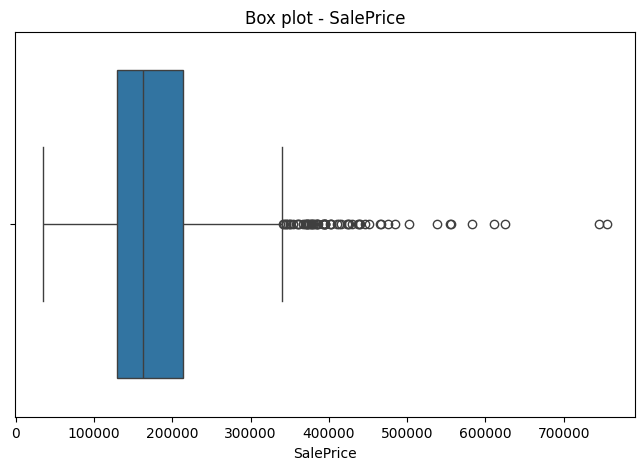

In [3]:
plt.figure(figsize=(8,5))
sns.boxplot(x = data['SalePrice'])
plt.title("Box plot - SalePrice")

plt.savefig(DIR_EDA/"Before_Log_Transform/SalePrice_distribution/box_plot_saleprice_distribution.png")
plt.show()


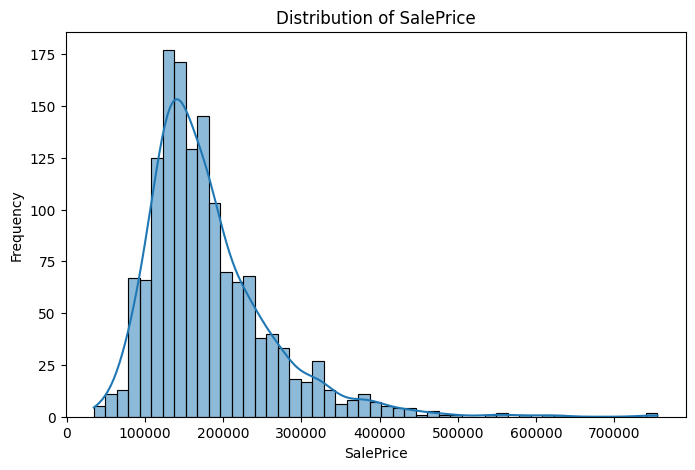

In [4]:
plt.figure(figsize=(8,5))
sns.histplot(data["SalePrice"], kde=True)

plt.title("Distribution of SalePrice")
plt.xlabel("SalePrice")
plt.ylabel("Frequency")

plt.savefig(DIR_EDA/"Before_Log_Transform/SalePrice_distribution/hist_plot_saleprice_distribution.png")
plt.show()

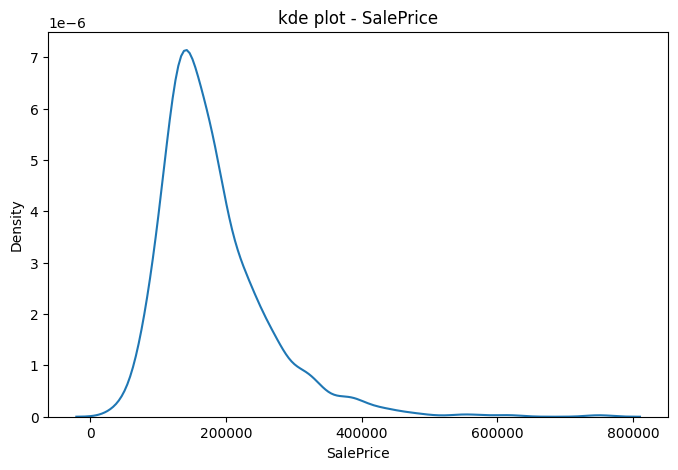

In [5]:
plt.figure(figsize=(8,5))
sns.kdeplot(data['SalePrice'])
plt.title("kde plot - SalePrice")

plt.savefig(DIR_EDA/"Before_Log_Transform/SalePrice_distribution/kde_plot_saleprice_distribution.png")
plt.show()


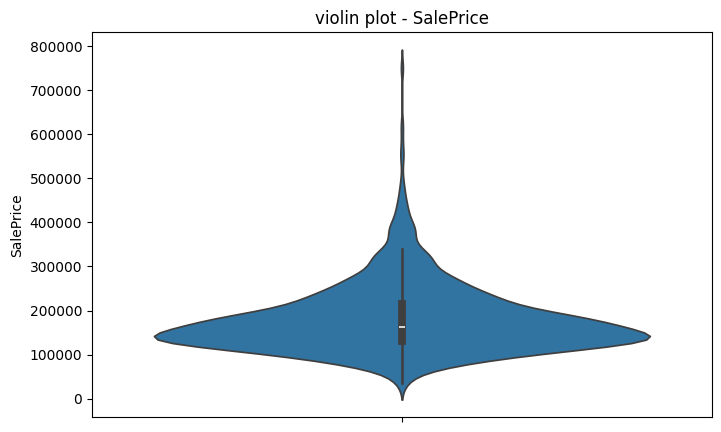

In [6]:
plt.figure(figsize=(8,5))
sns.violinplot(data['SalePrice'])
plt.title("violin plot - SalePrice")
plt.savefig(DIR_EDA/"Before_Log_Transform/SalePrice_distribution/violin_plot_saleprice_distribution.png")
plt.show()

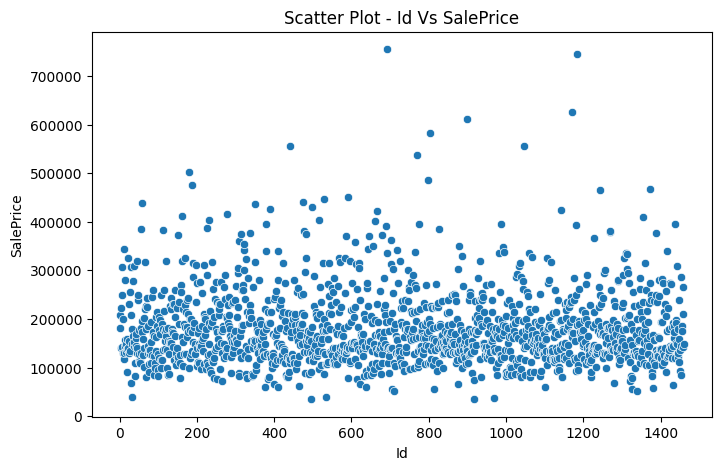

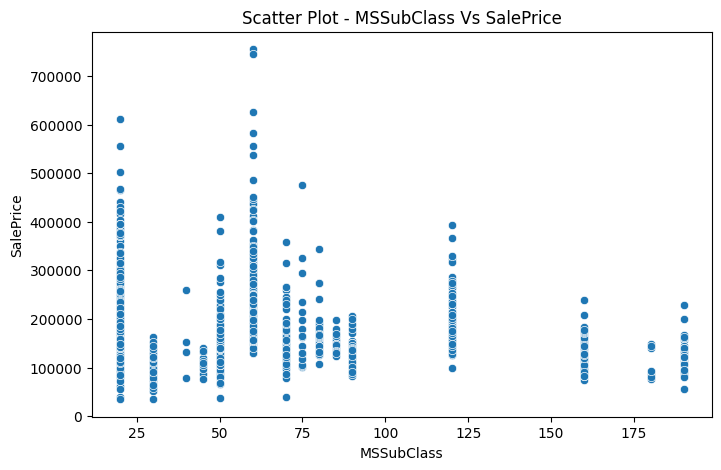

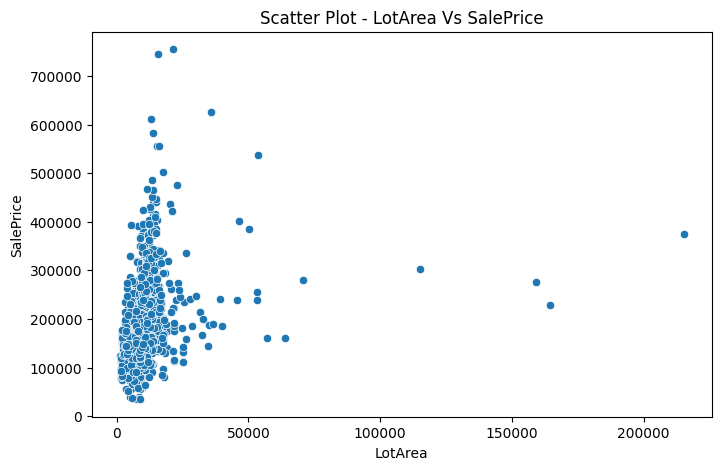

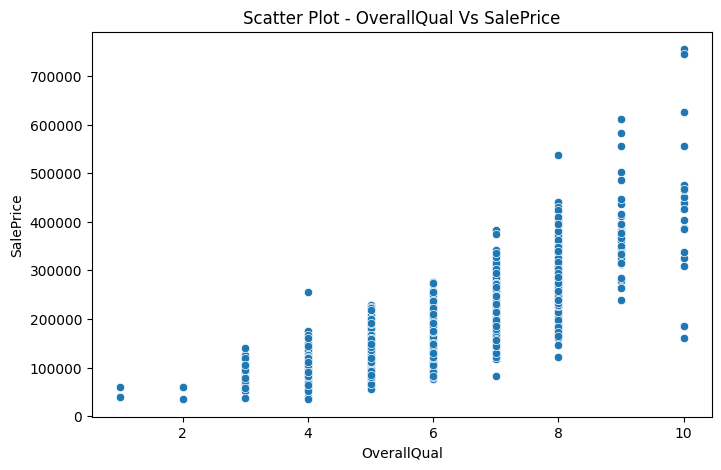

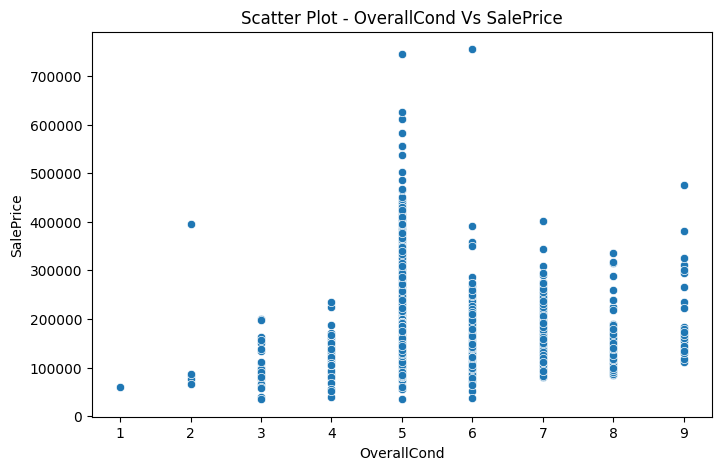

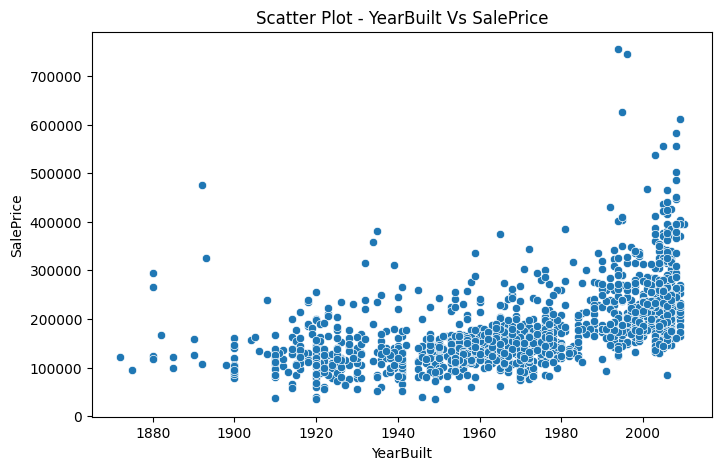

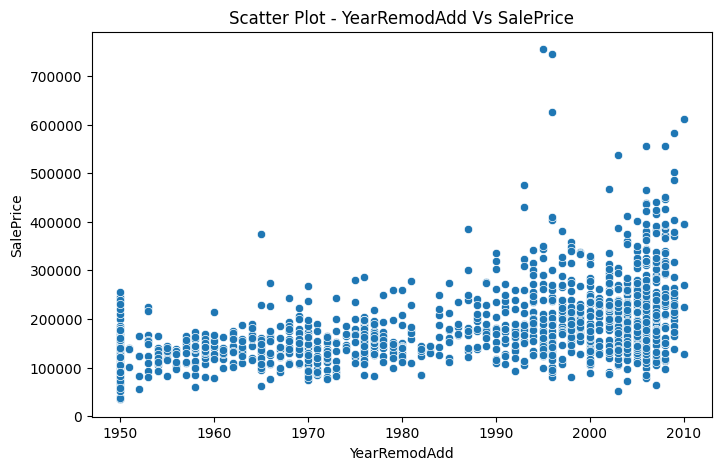

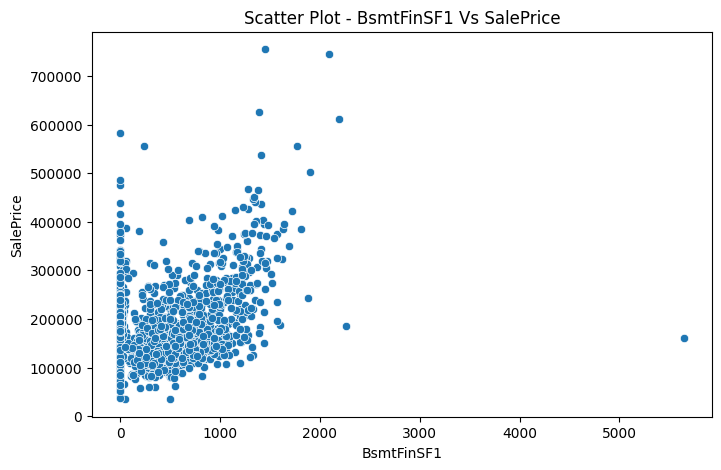

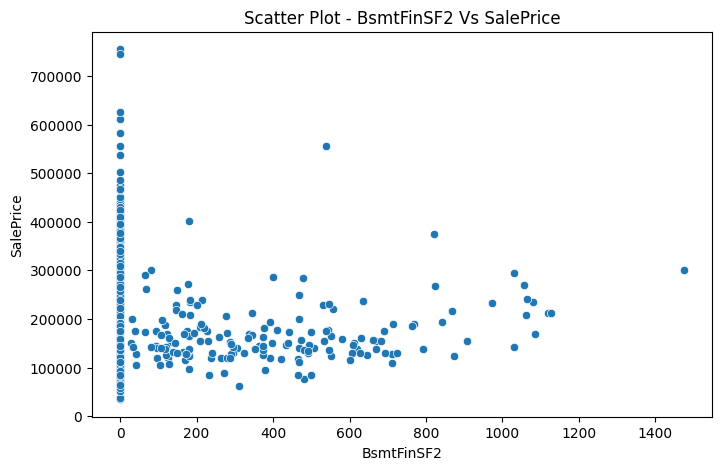

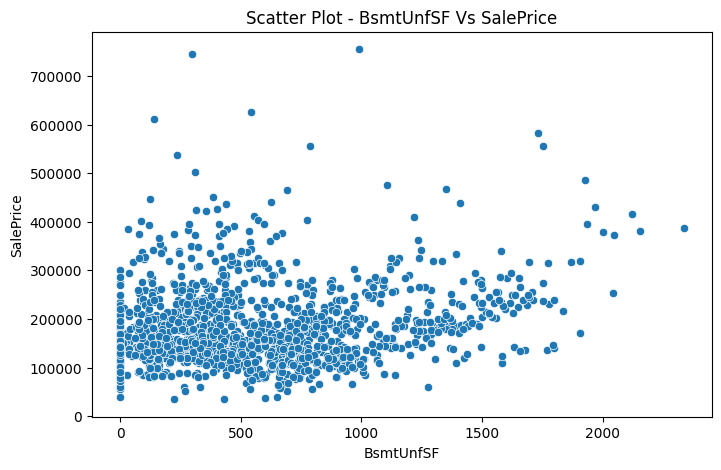

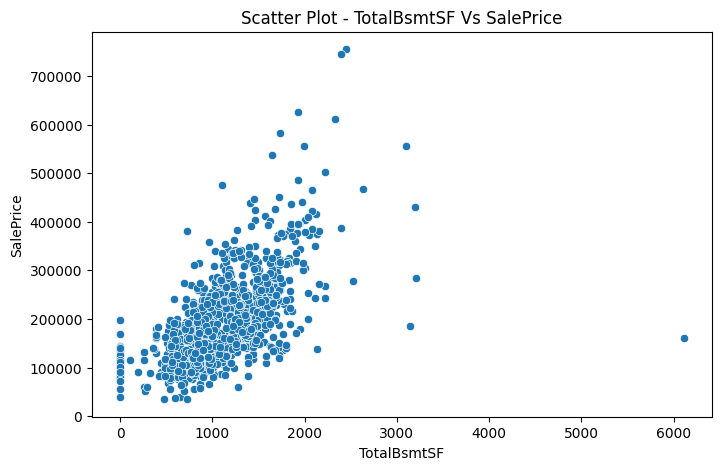

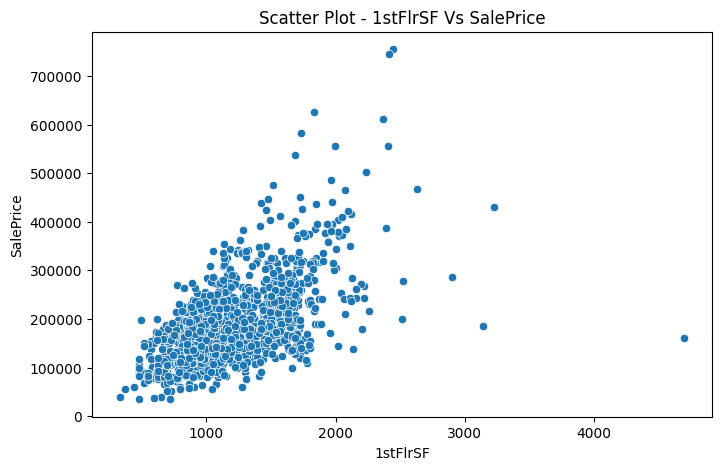

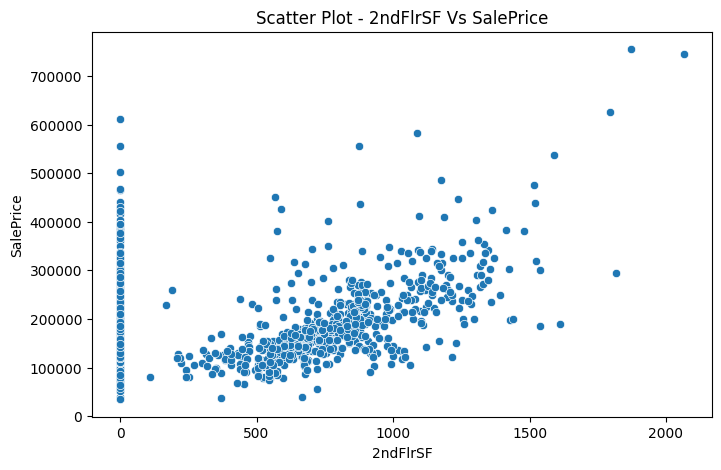

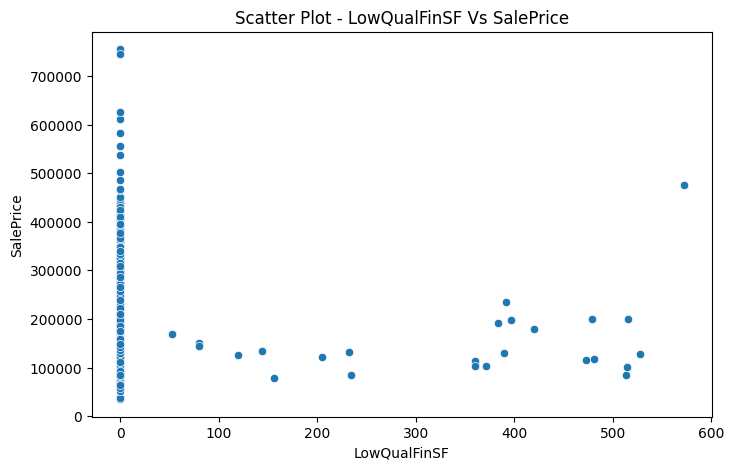

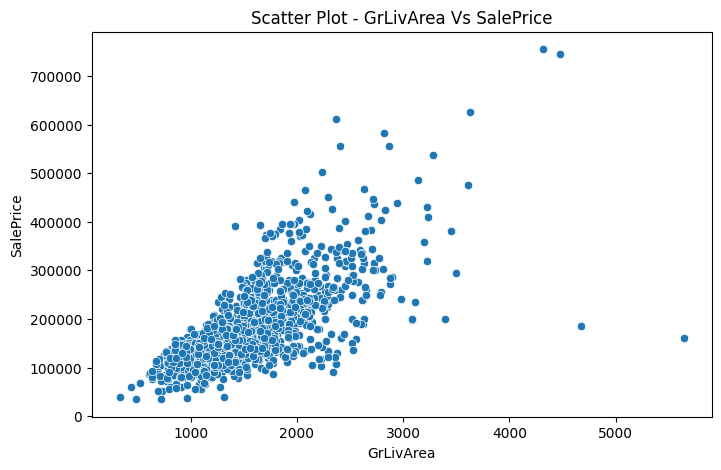

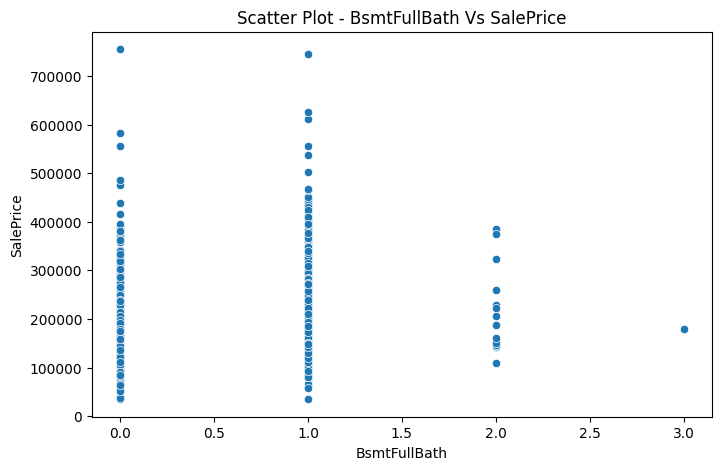

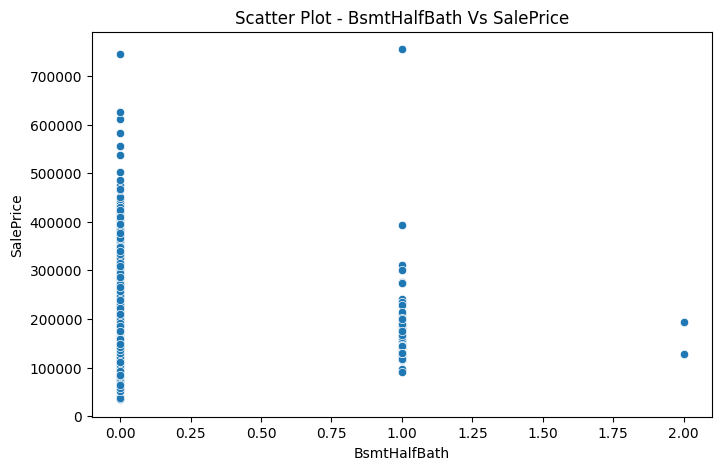

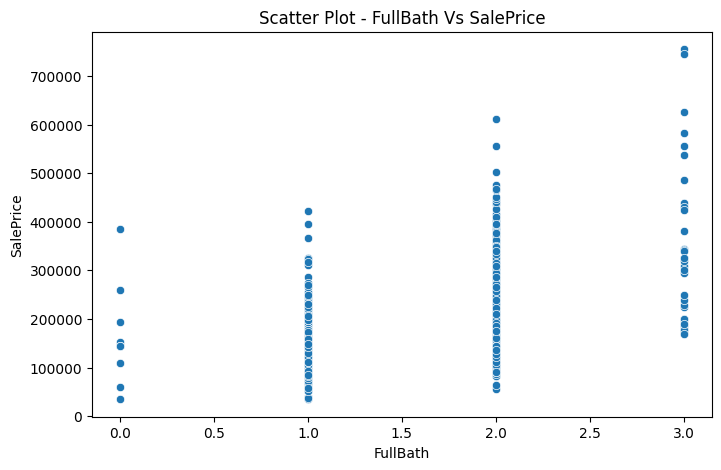

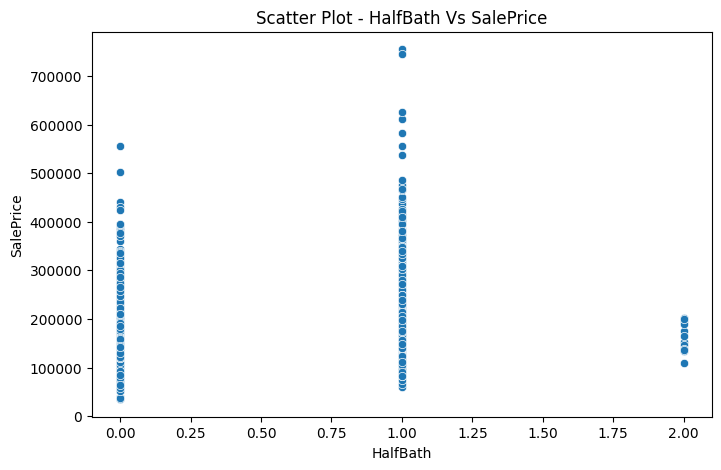

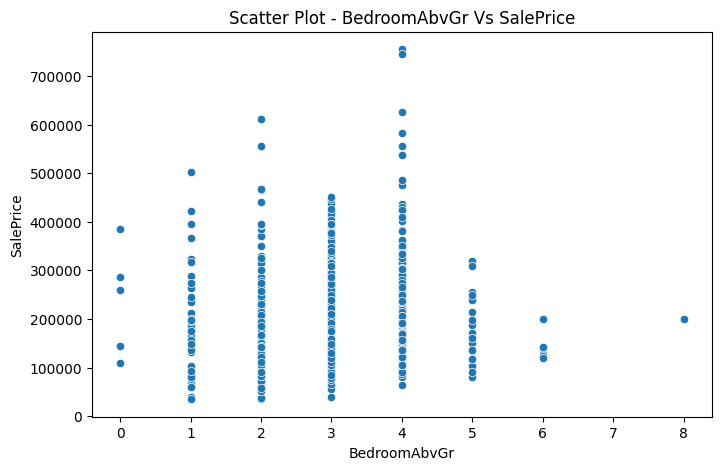

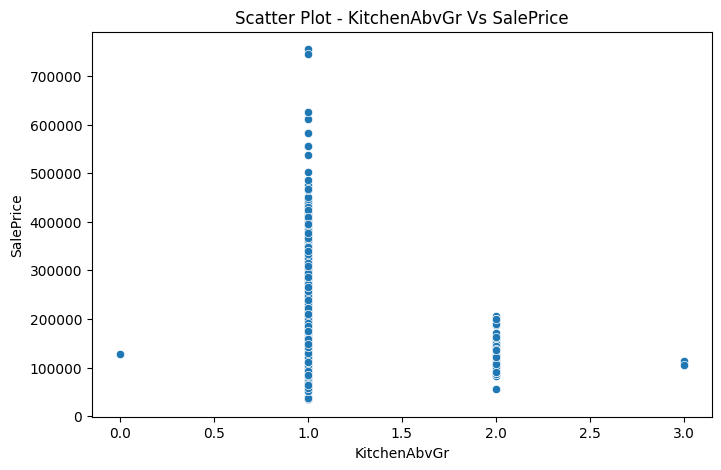

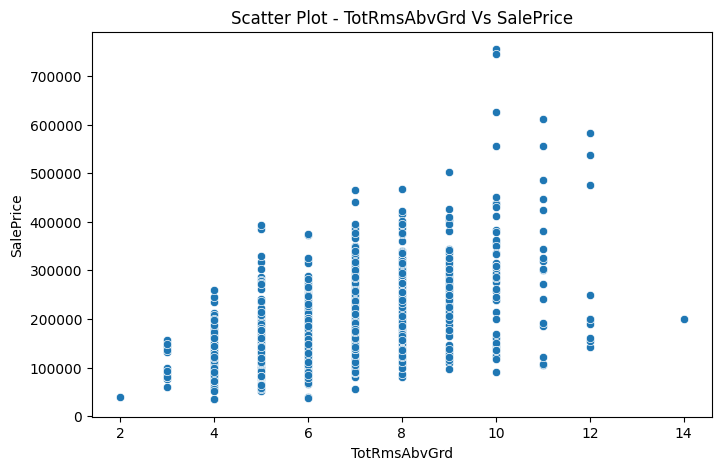

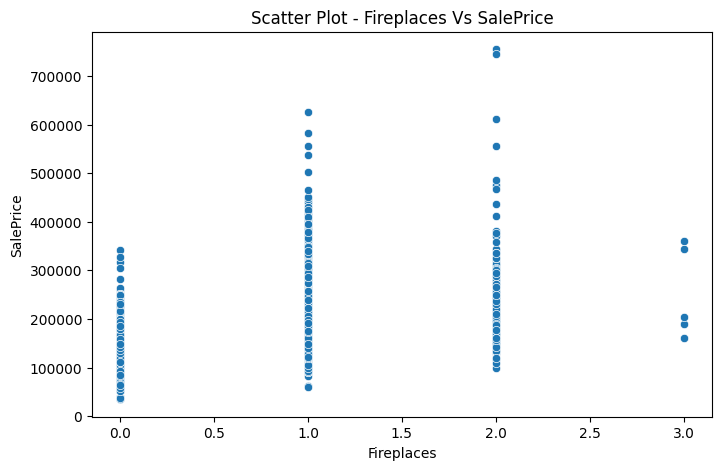

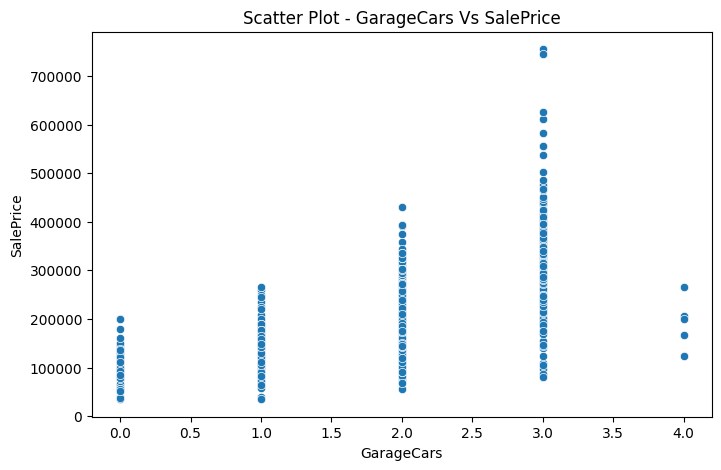

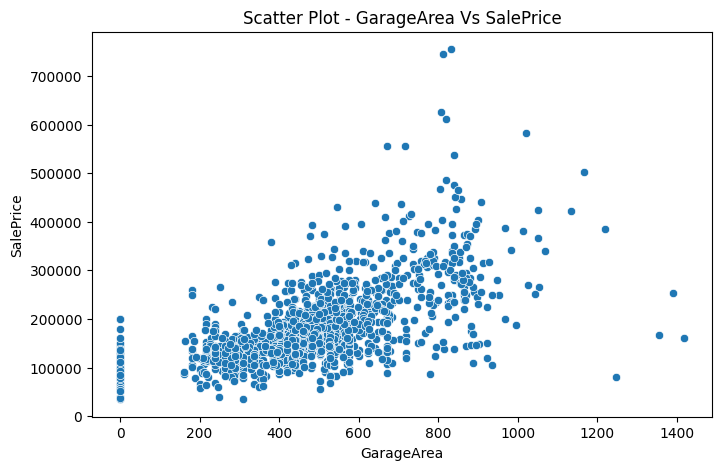

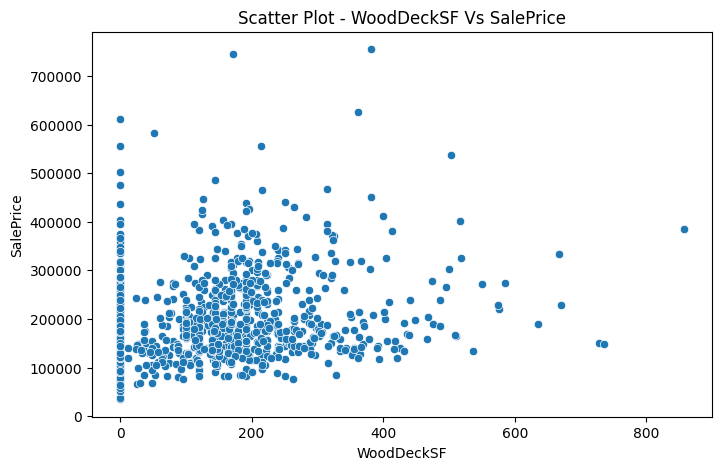

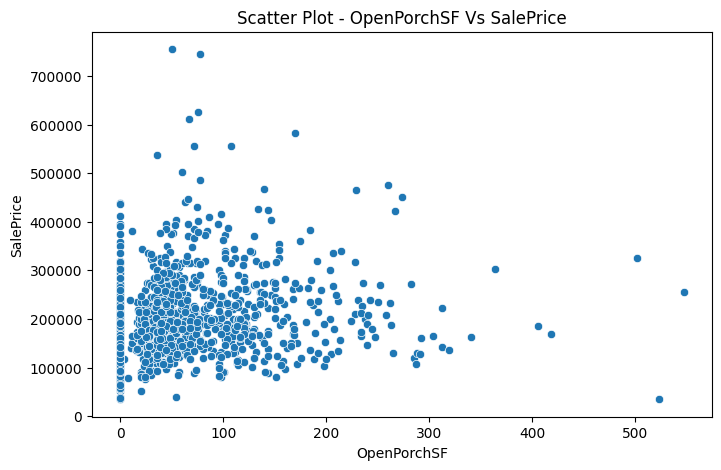

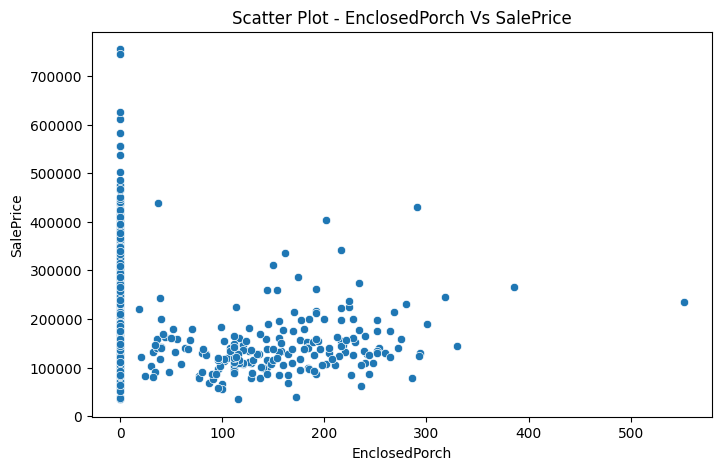

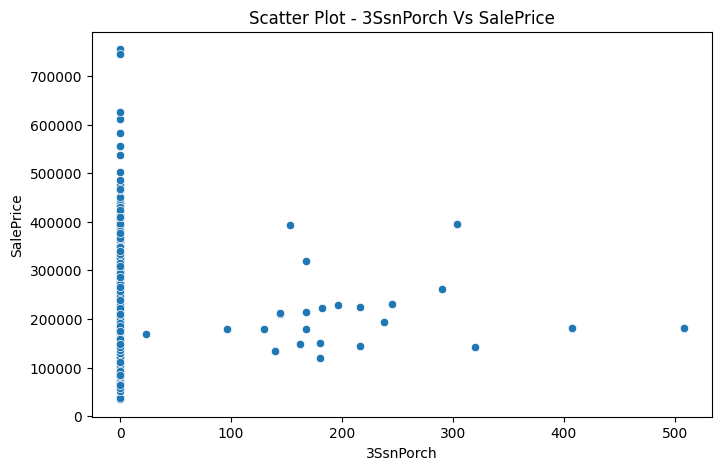

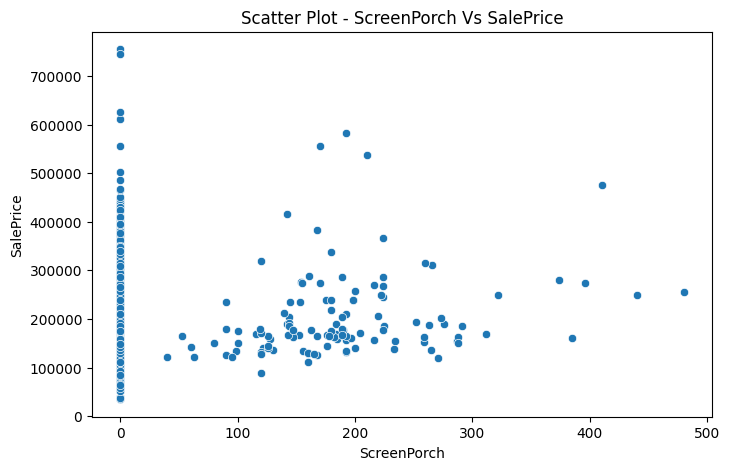

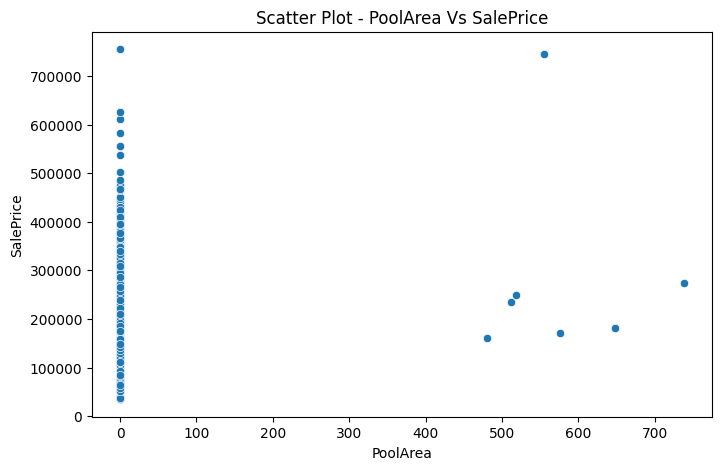

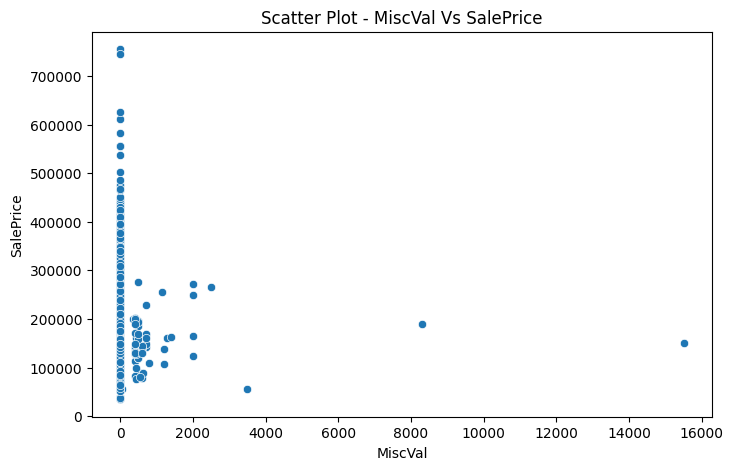

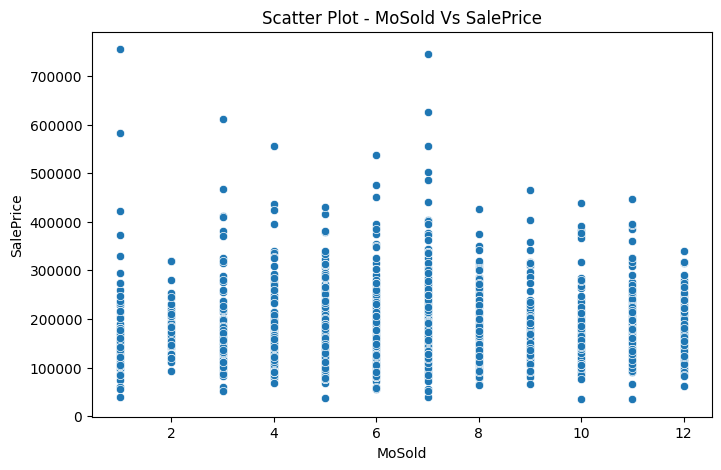

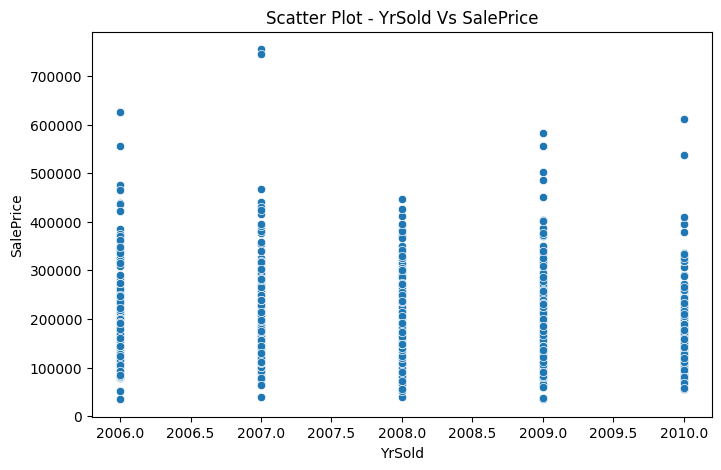

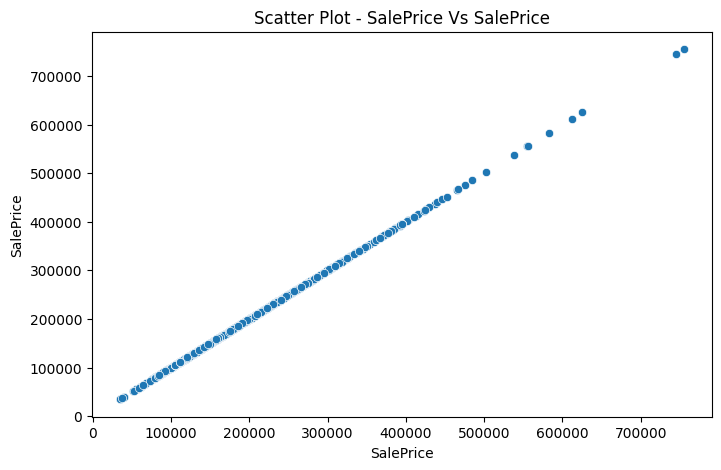

In [7]:
#Scatter plot
num_cols = data.select_dtypes(include = ["int64"]).columns
for i in num_cols:
    plt.figure(figsize=(8,5))
    sns.scatterplot(x = i, y = 'SalePrice', data = data)
    plt.title(f"Scatter Plot - {i} Vs SalePrice")

    plt.savefig(DIR_EDA/f"Before_Log_Transform/scatter_plots_salesprice_vs_all_num_cols/scatter_plot_{i}_vs_saleprice.png")
    plt.show()

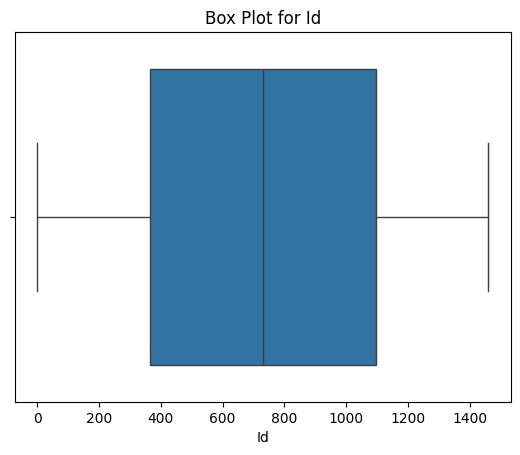

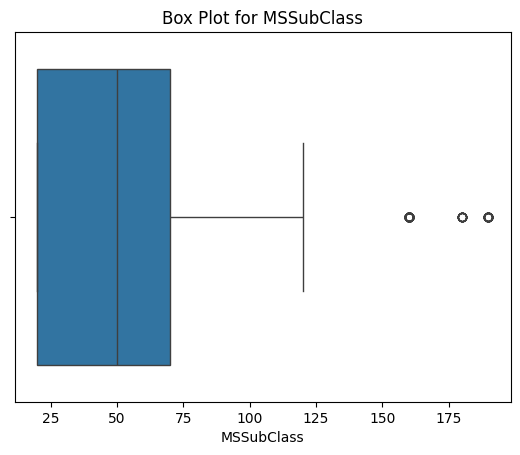

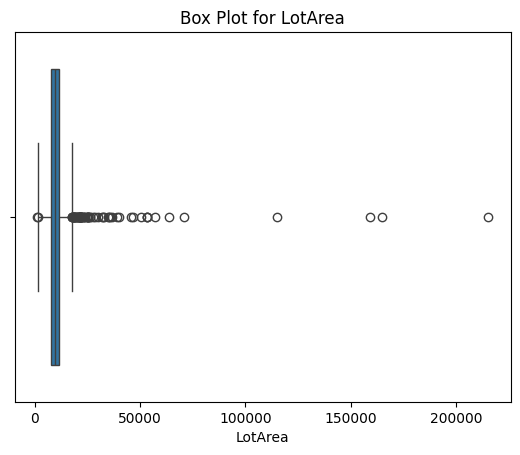

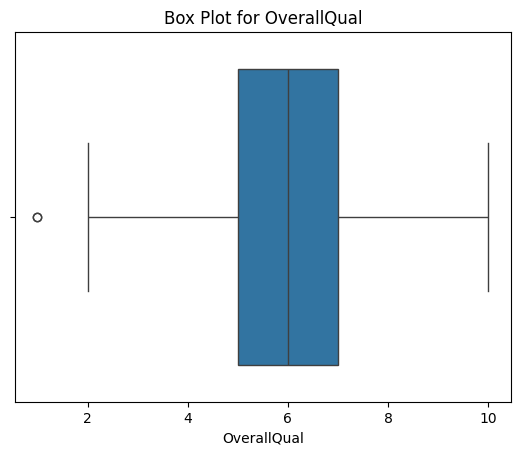

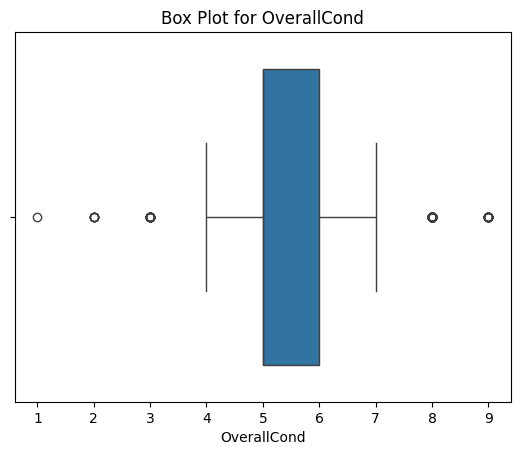

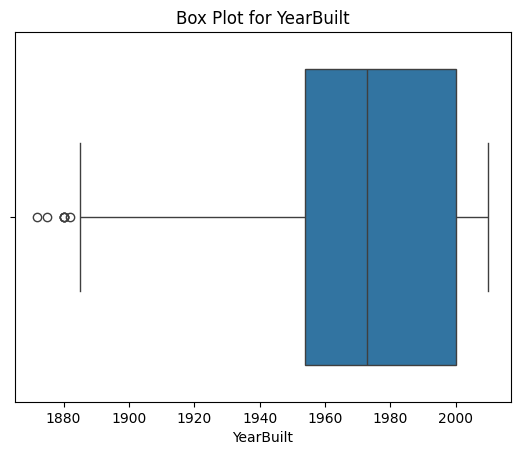

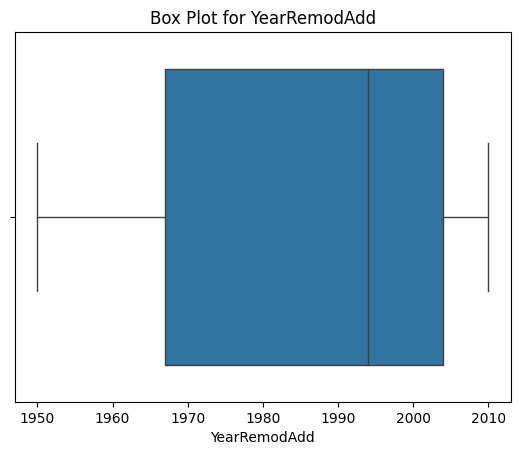

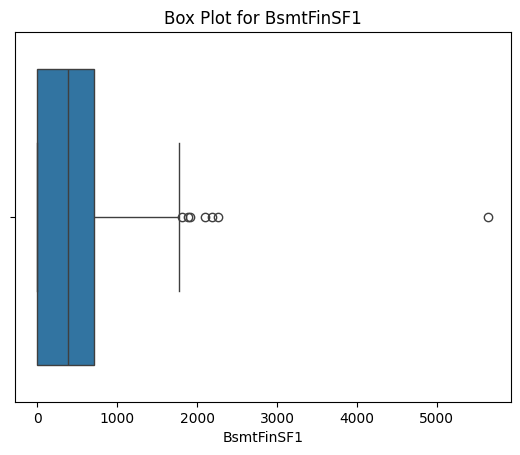

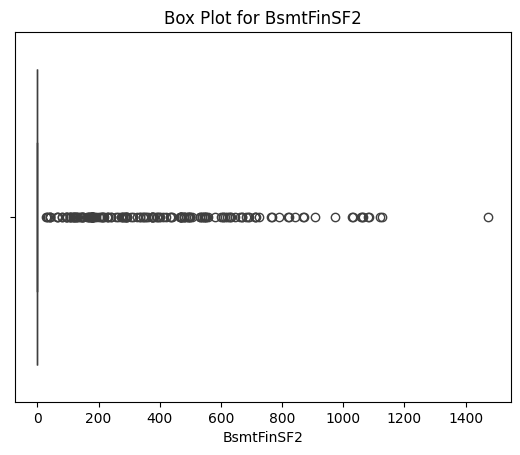

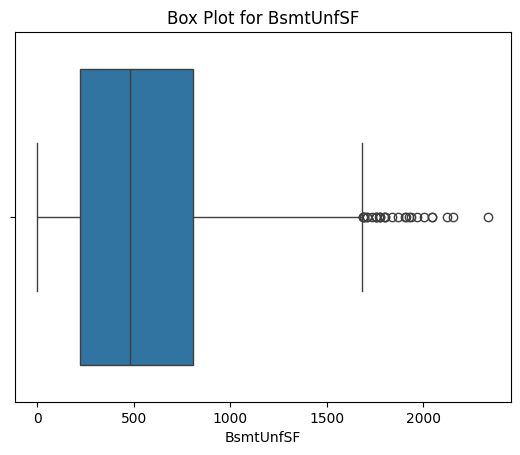

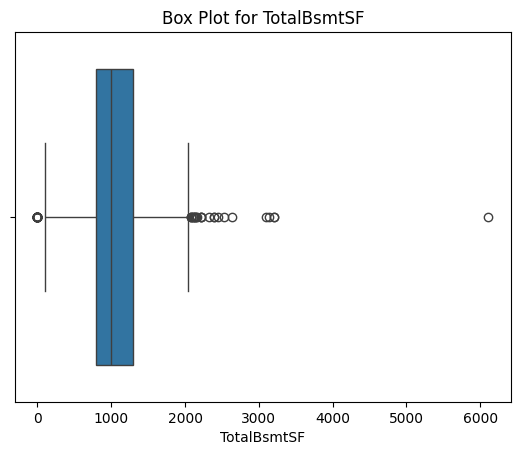

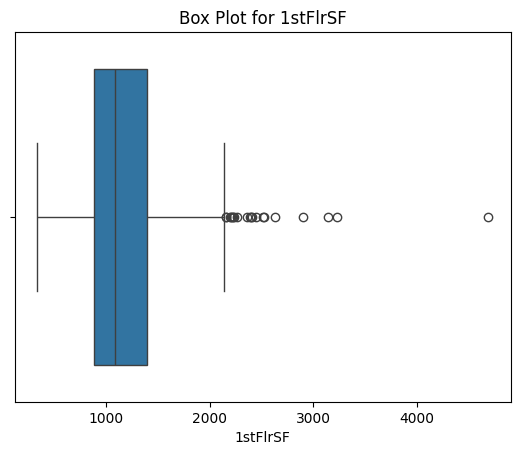

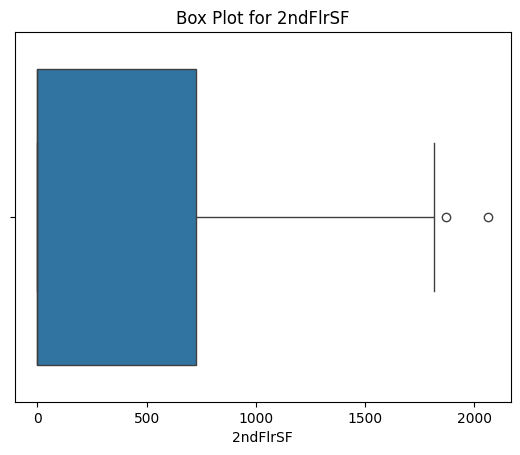

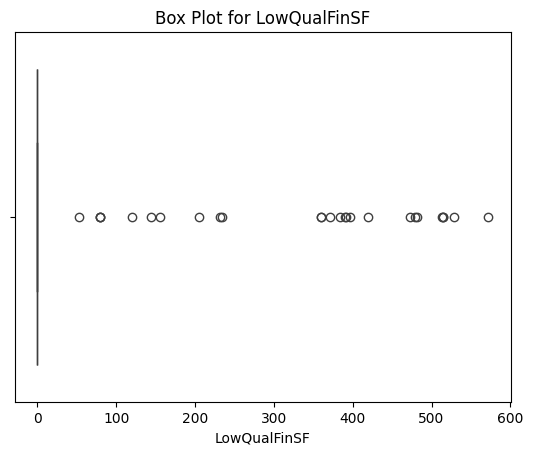

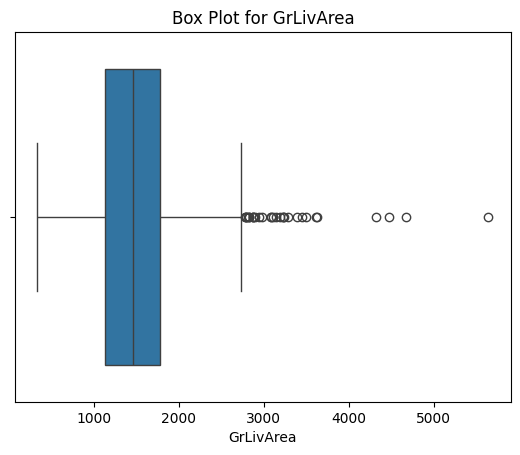

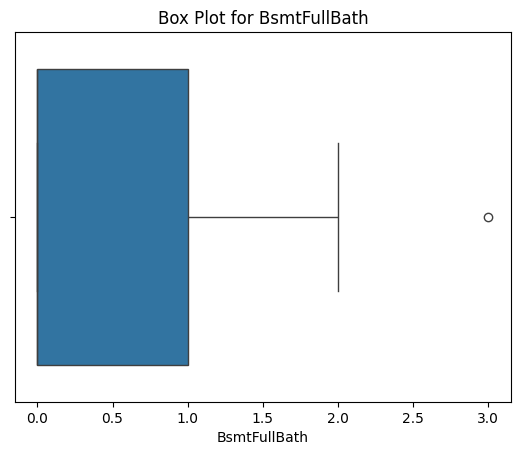

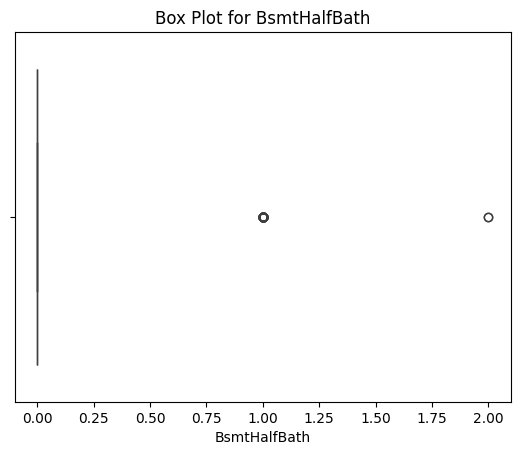

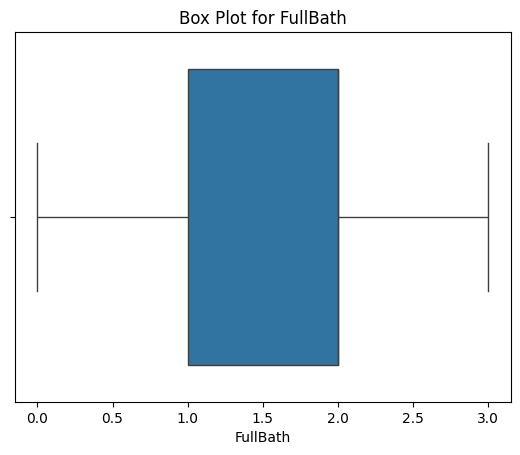

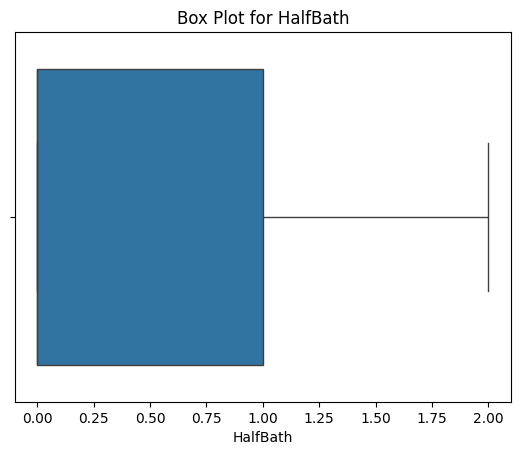

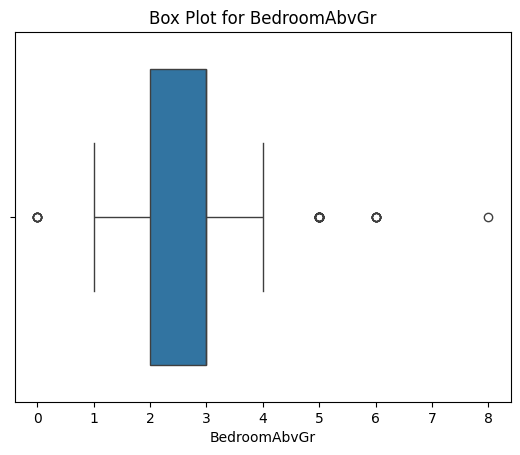

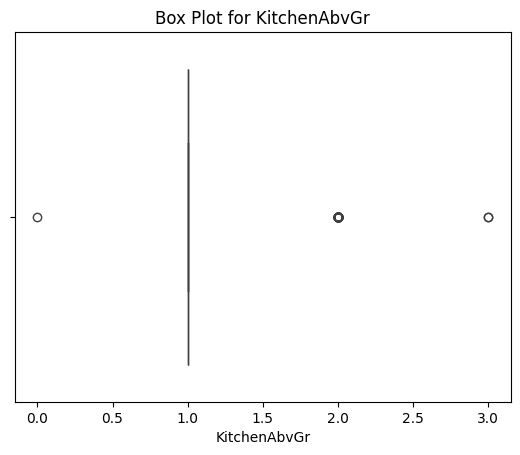

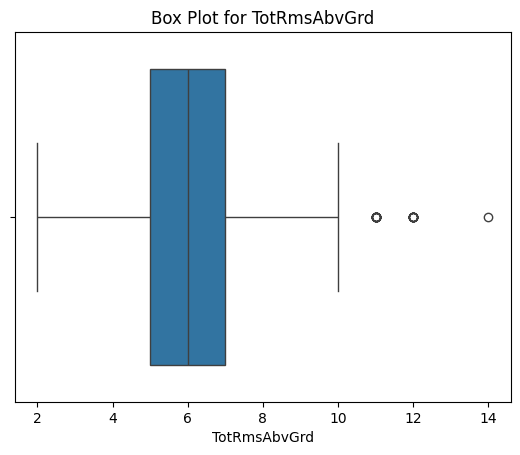

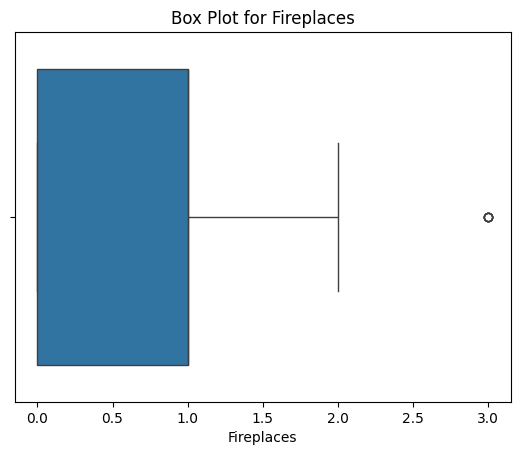

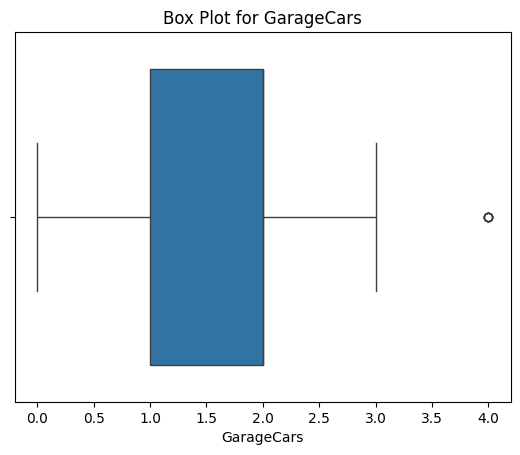

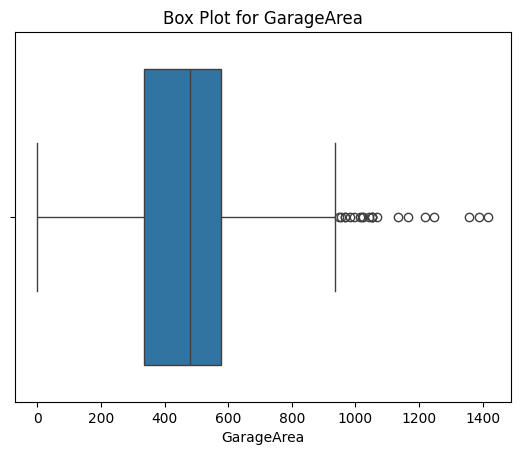

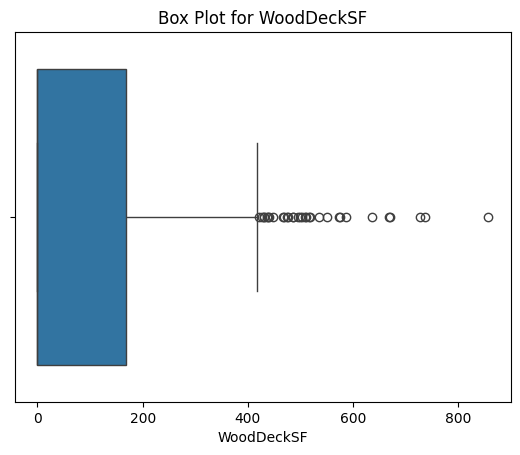

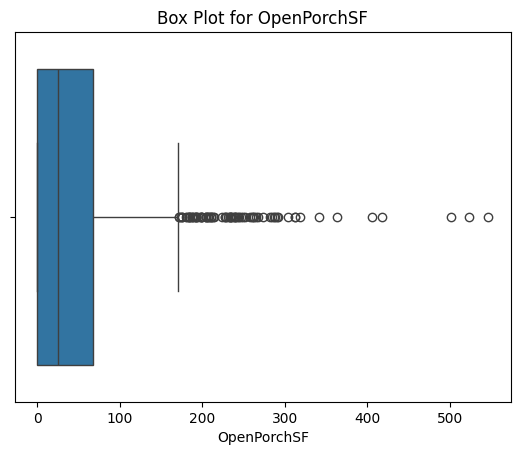

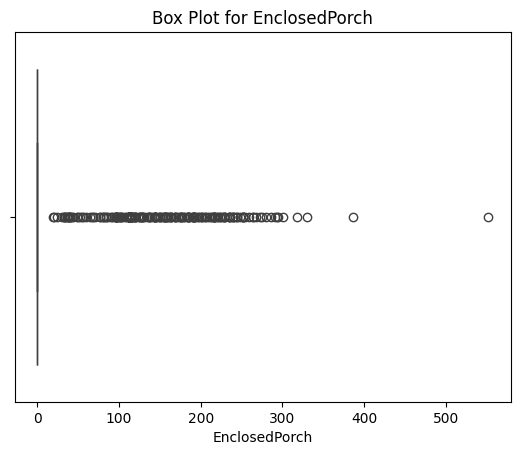

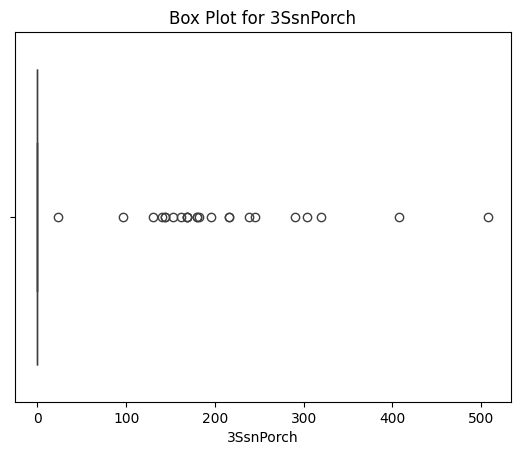

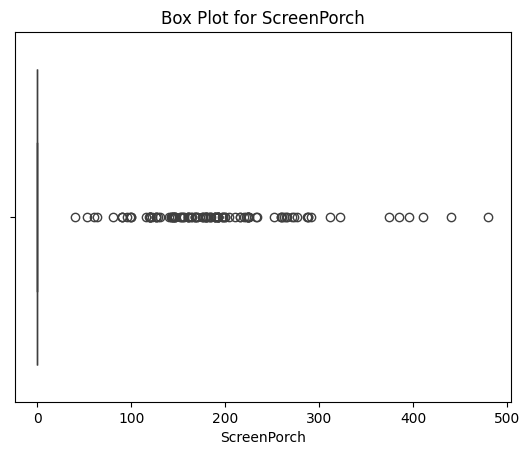

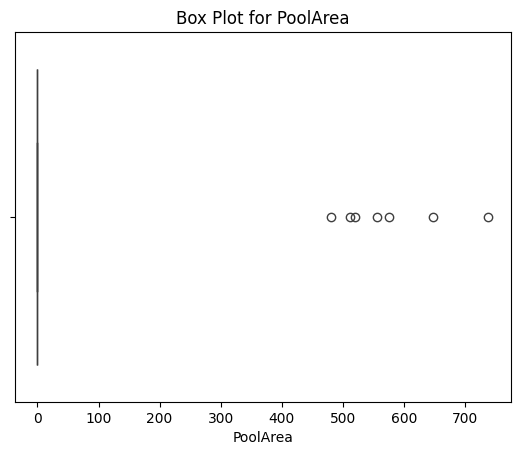

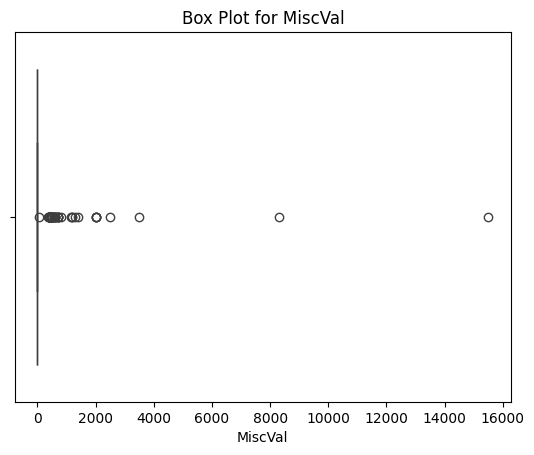

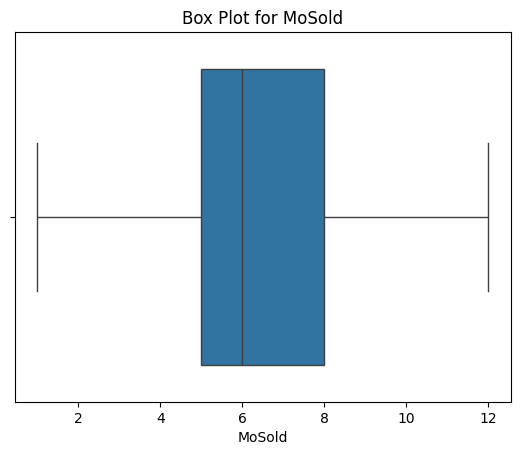

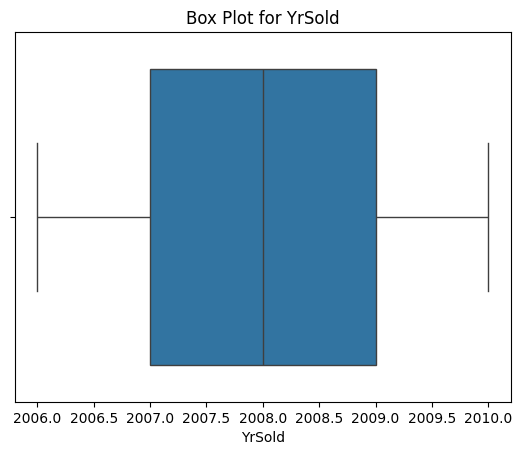

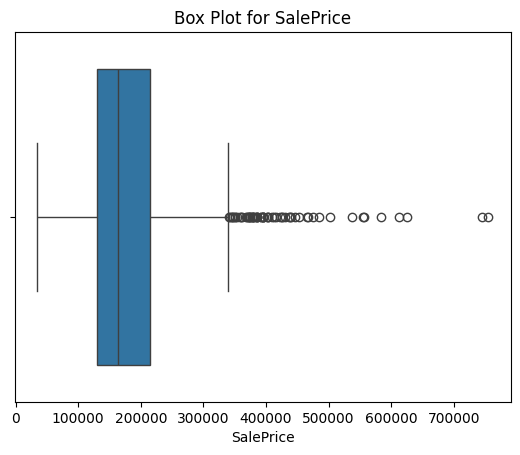

In [8]:
#Boxplot for num_cols
for i in num_cols:
    sns.boxplot(x = i, data = data)
    plt.title(f"Box Plot for {i}")
    
    plt.savefig(DIR_EDA/f"Before_Log_Transform/BoxPlots_for_num_cols/scatter_plot_{i}_vs_saleprice.png")

    plt.show()

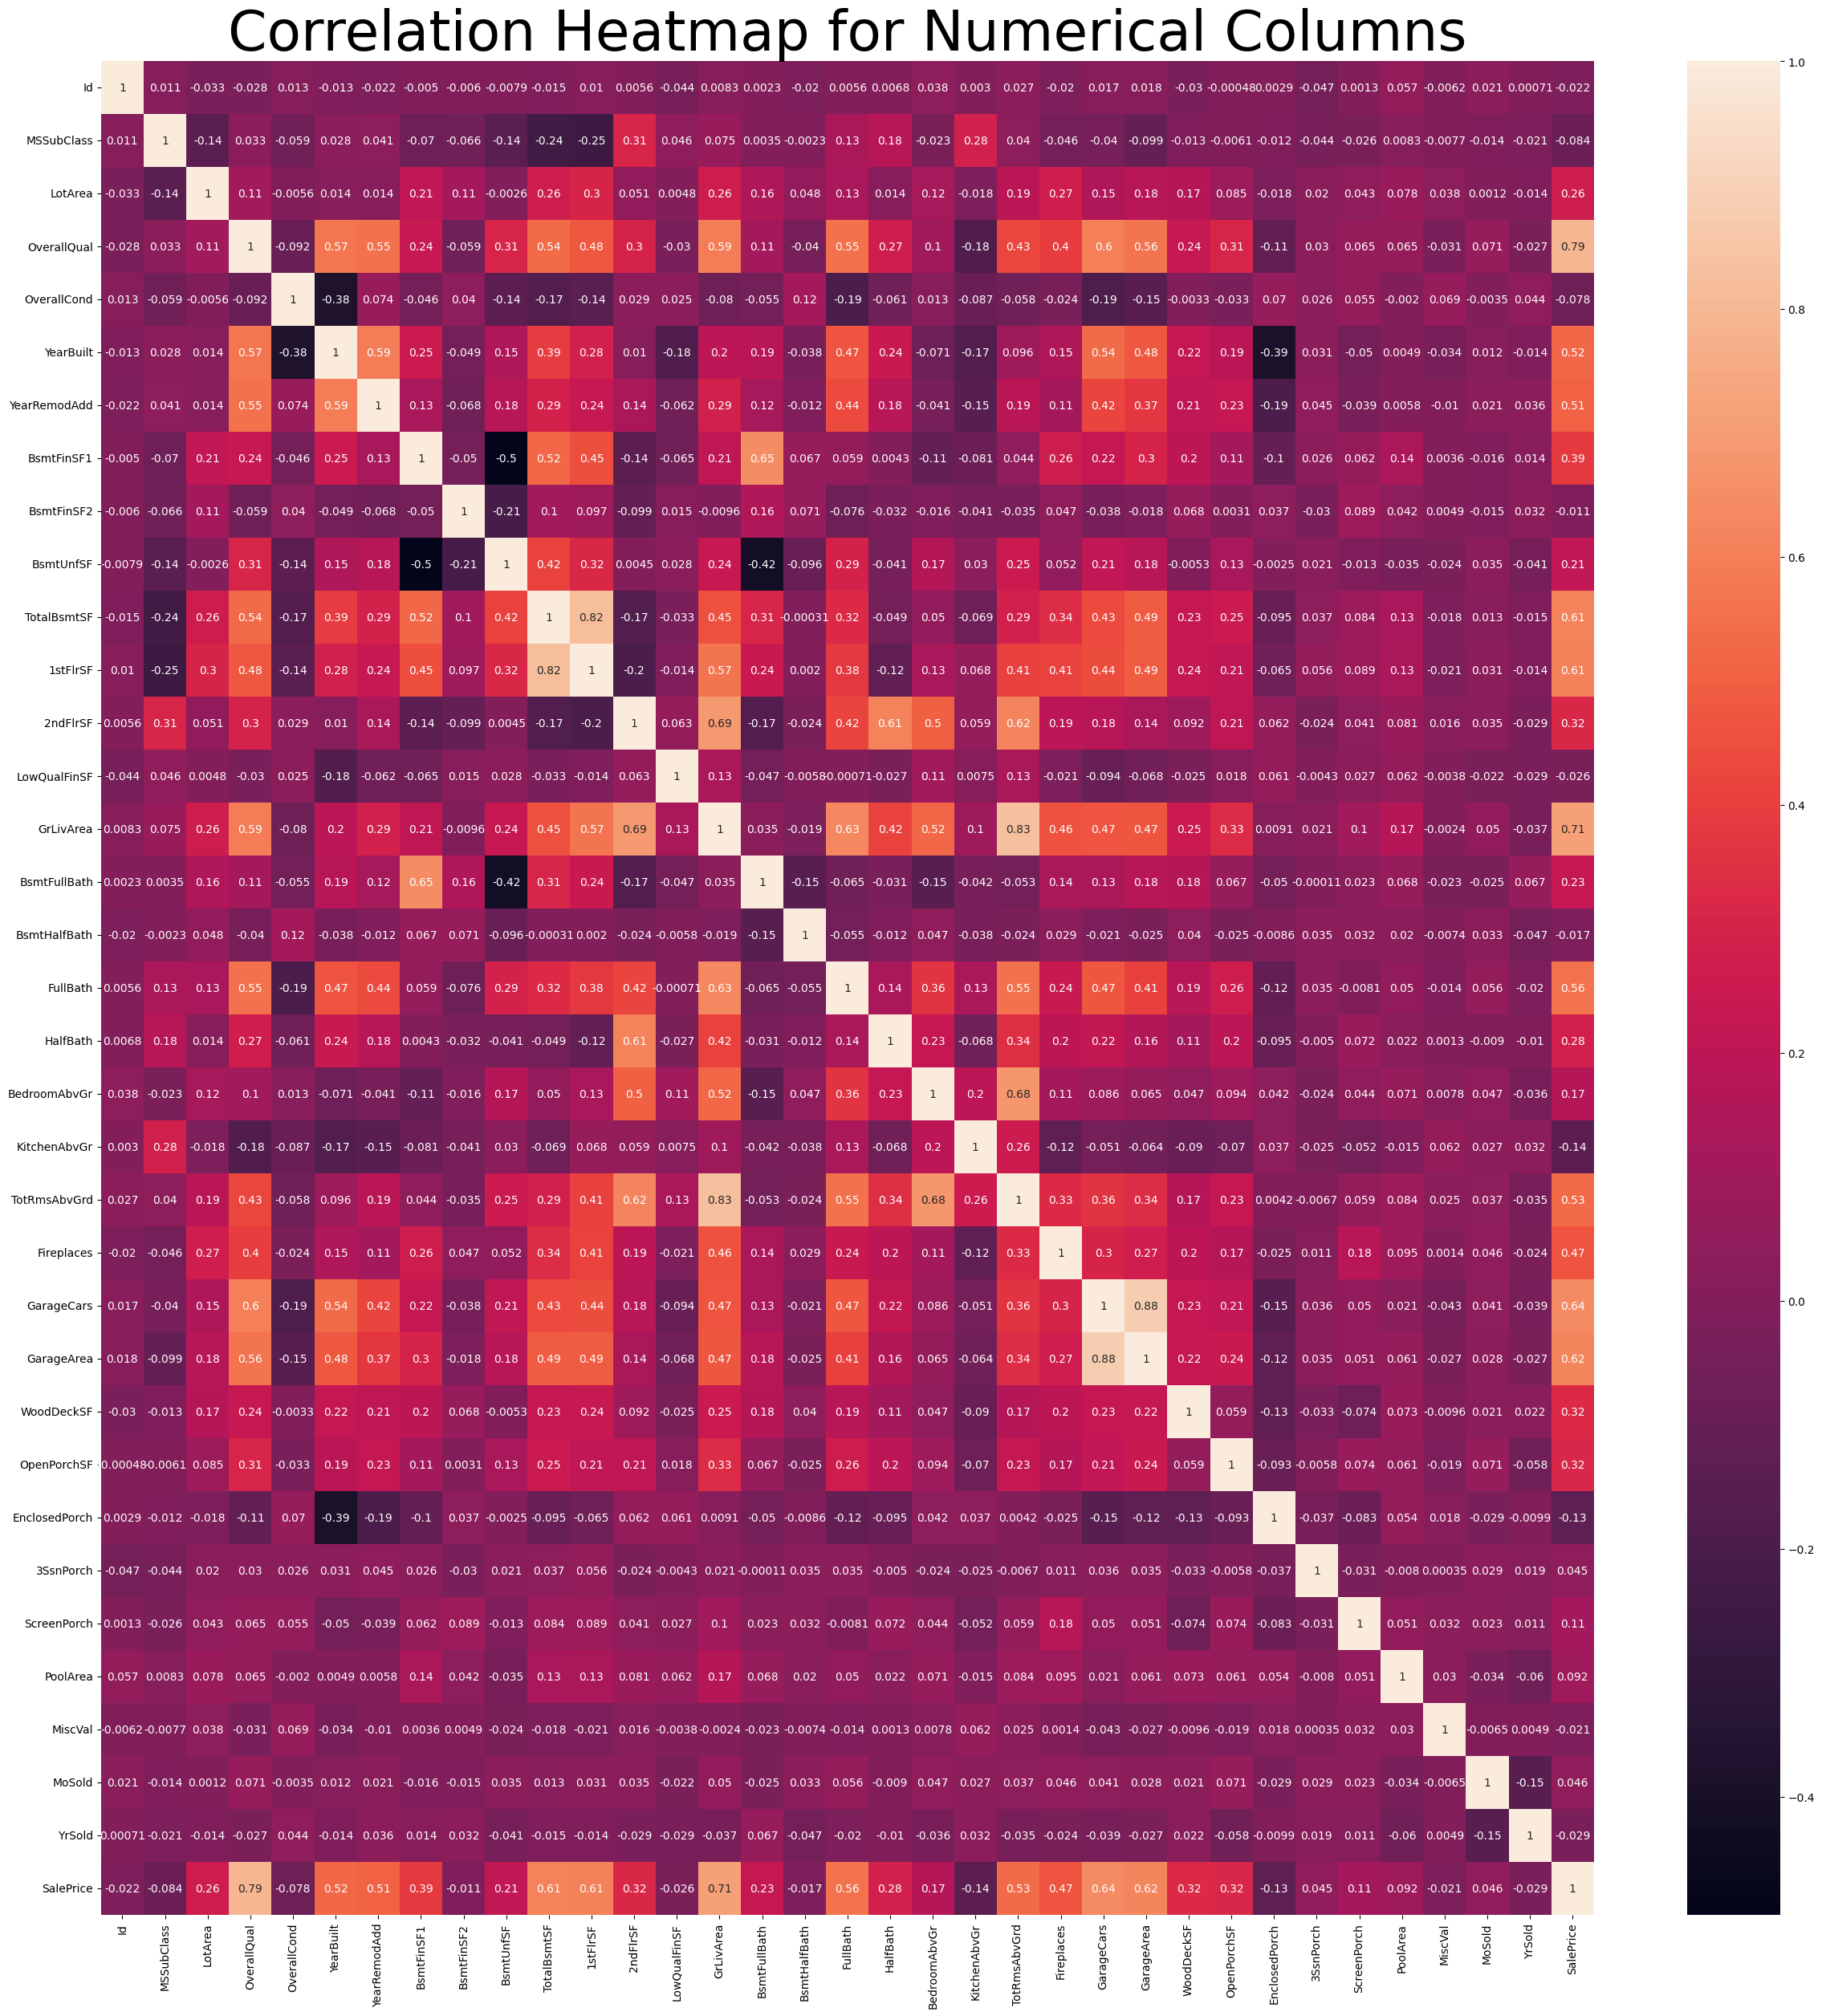

In [9]:
plt.figure(figsize = (30,30))
sns.heatmap(data[num_cols].corr(),annot = True)
plt.title("Correlation Heatmap for Numerical Columns", fontsize = 50)
plt.savefig(DIR_EDA/f"Before_Log_Transform/heatmap_num_cols/heatmap_for_numerical_cols.png")

plt.show()

In [10]:
data["SalePrice"] = np.log1p(data["SalePrice"])
data

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,12.247699
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,12.109016
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,12.317171
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,11.849405
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,12.429220
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1455,1456,60,RL,62.0,7917,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,8,2007,WD,Normal,12.072547
1456,1457,20,RL,85.0,13175,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,MnPrv,NaN,0,2,2010,WD,Normal,12.254868
1457,1458,70,RL,66.0,9042,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,GdPrv,Shed,2500,5,2010,WD,Normal,12.493133
1458,1459,20,RL,68.0,9717,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,4,2010,WD,Normal,11.864469


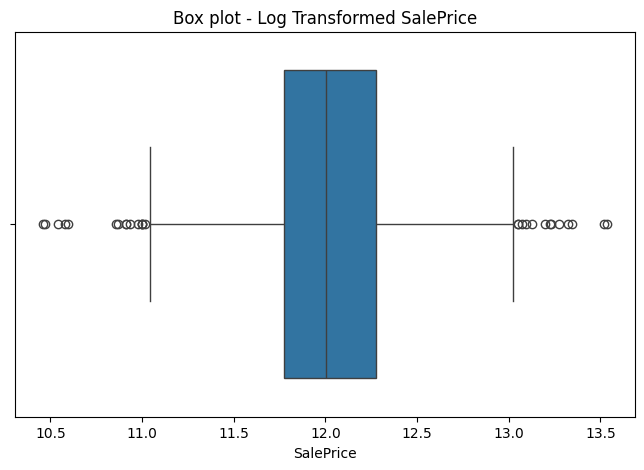

In [11]:
plt.figure(figsize=(8,5))
sns.boxplot(x=data["SalePrice"])
plt.title("Box plot - Log Transformed SalePrice")
plt.savefig(DIR_EDA/"After_Log_Transform/Boxplot_SalePrice_distribution/box_plot_log_transformed_saleprice_distribution.png")
plt.show()

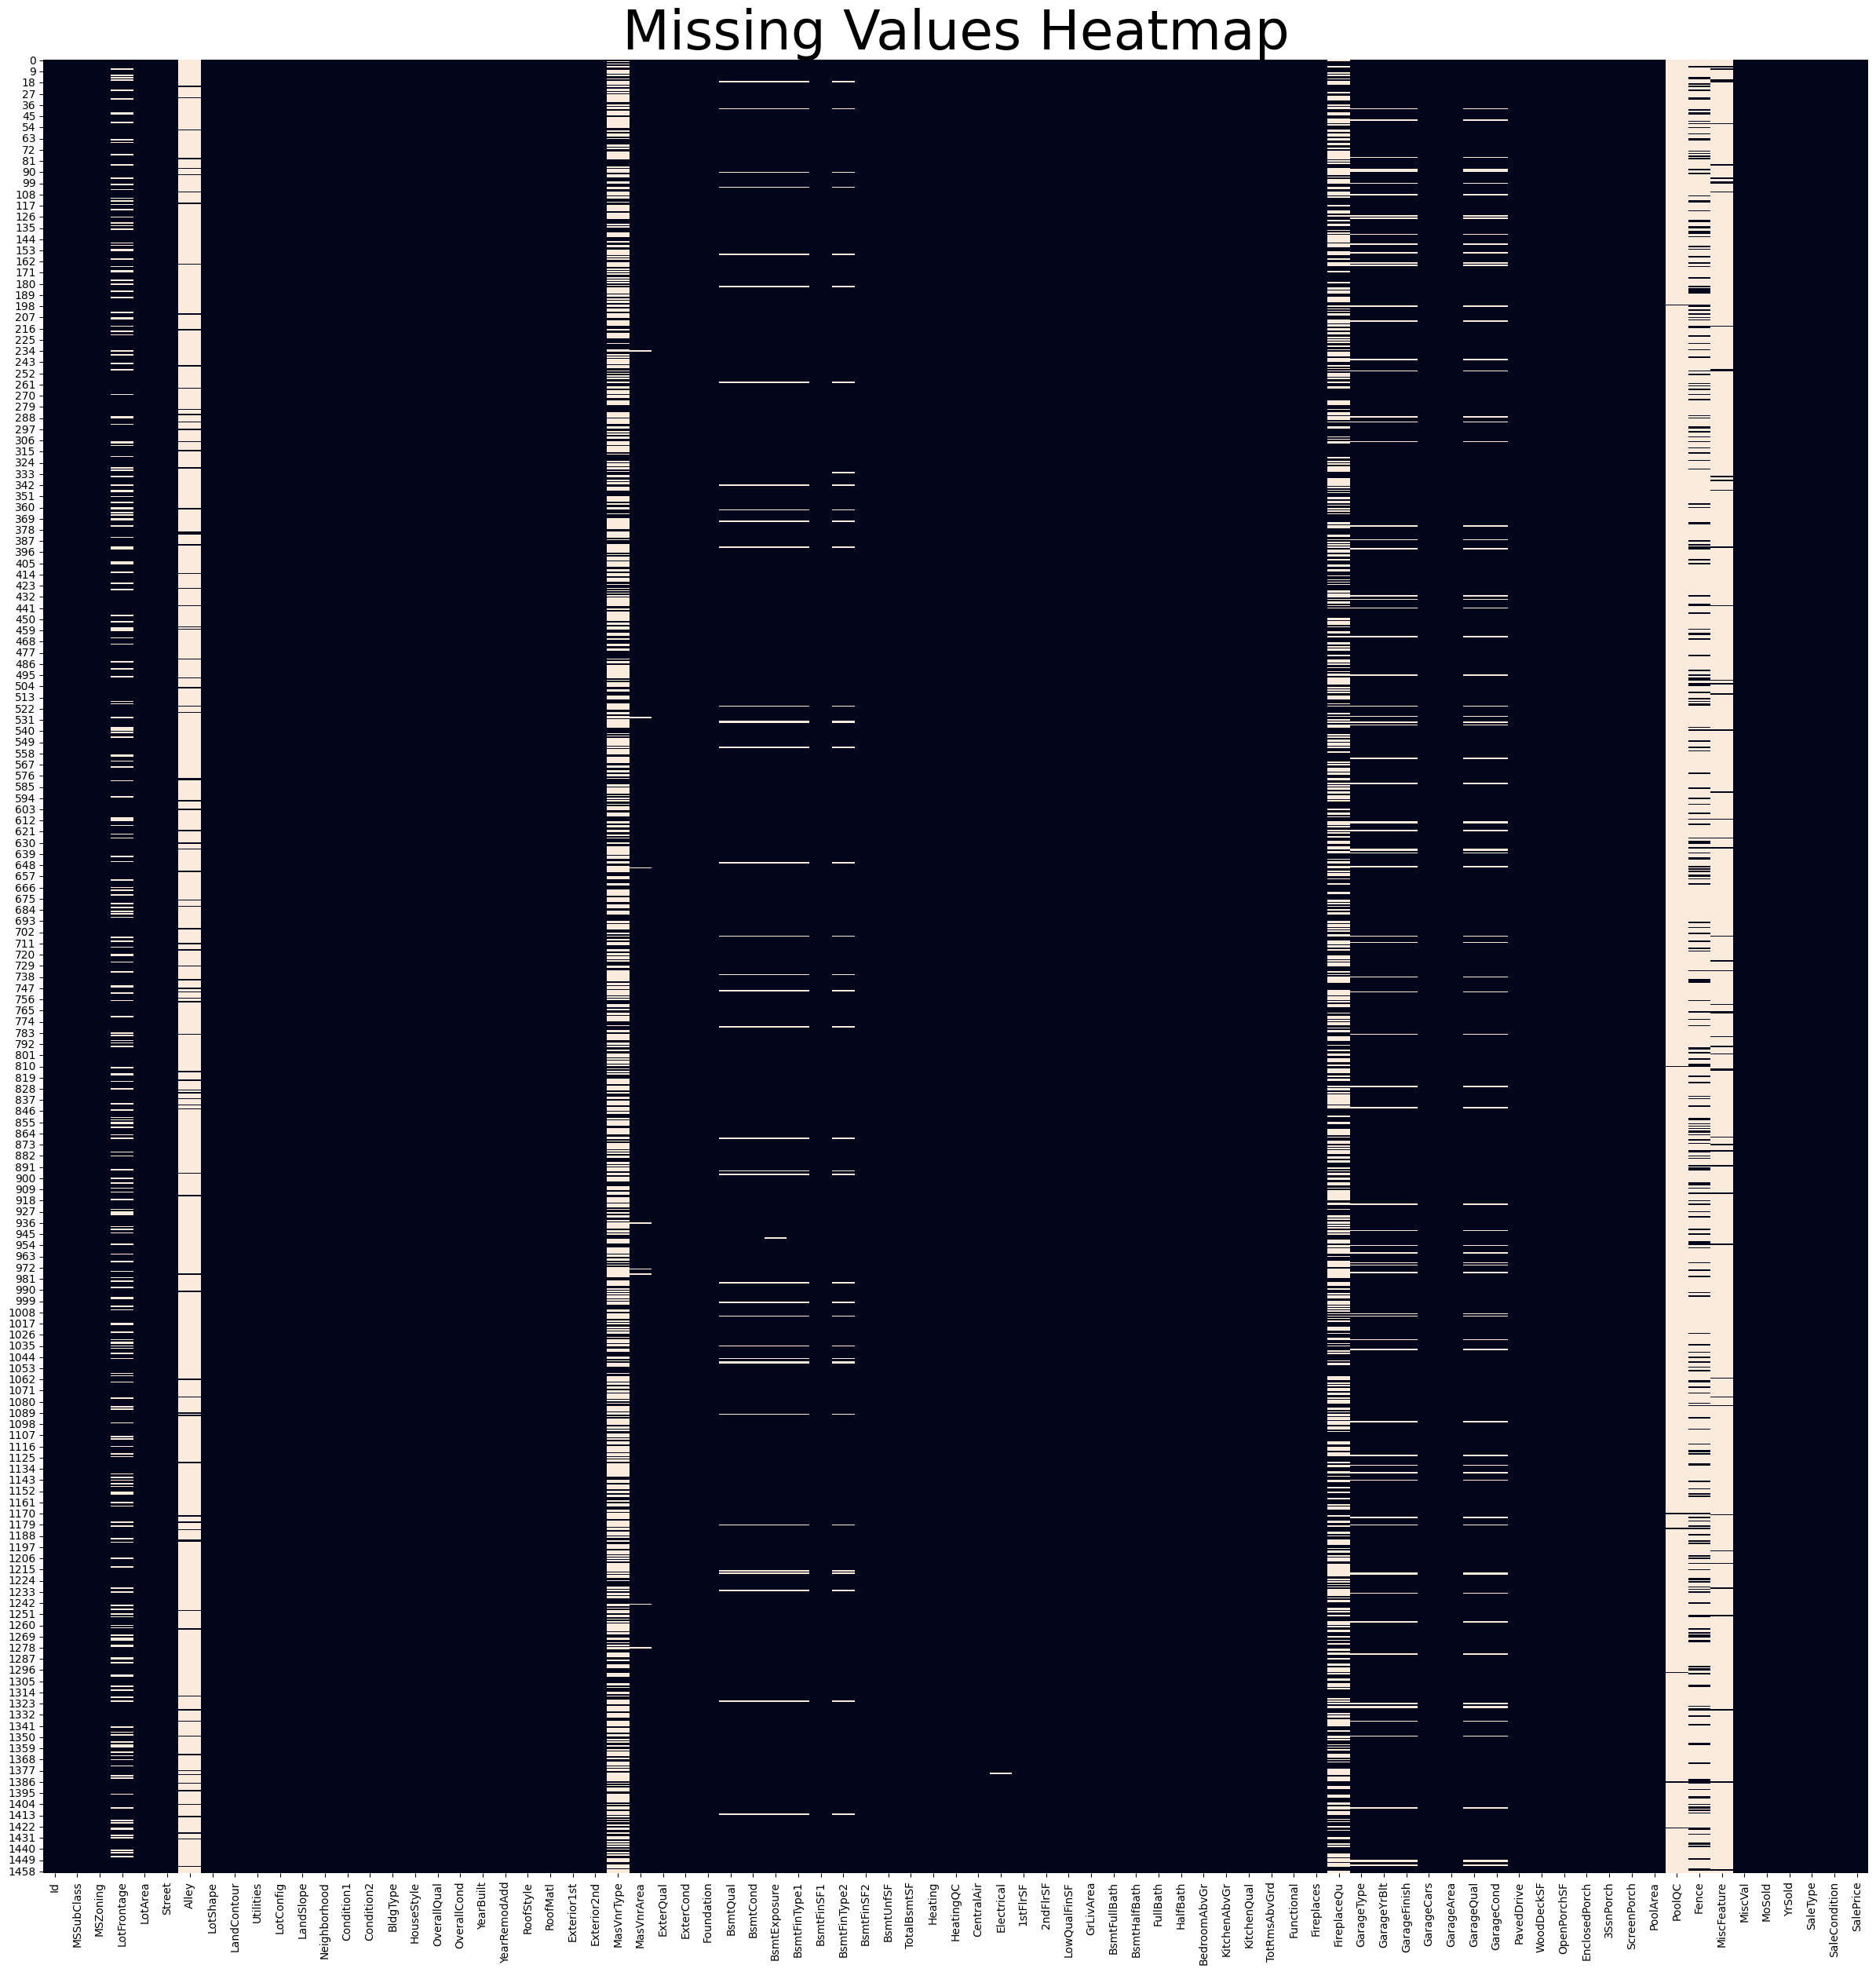

In [12]:
plt.figure(figsize = (30,30))
sns.heatmap(data.isnull(), cbar=False)
plt.title("Missing Values Heatmap", fontsize = 50)
plt.savefig(DIR_EDA/"After_Log_Transform/missing_values_heatmap/missing_values_heatmap.png")
plt.show()

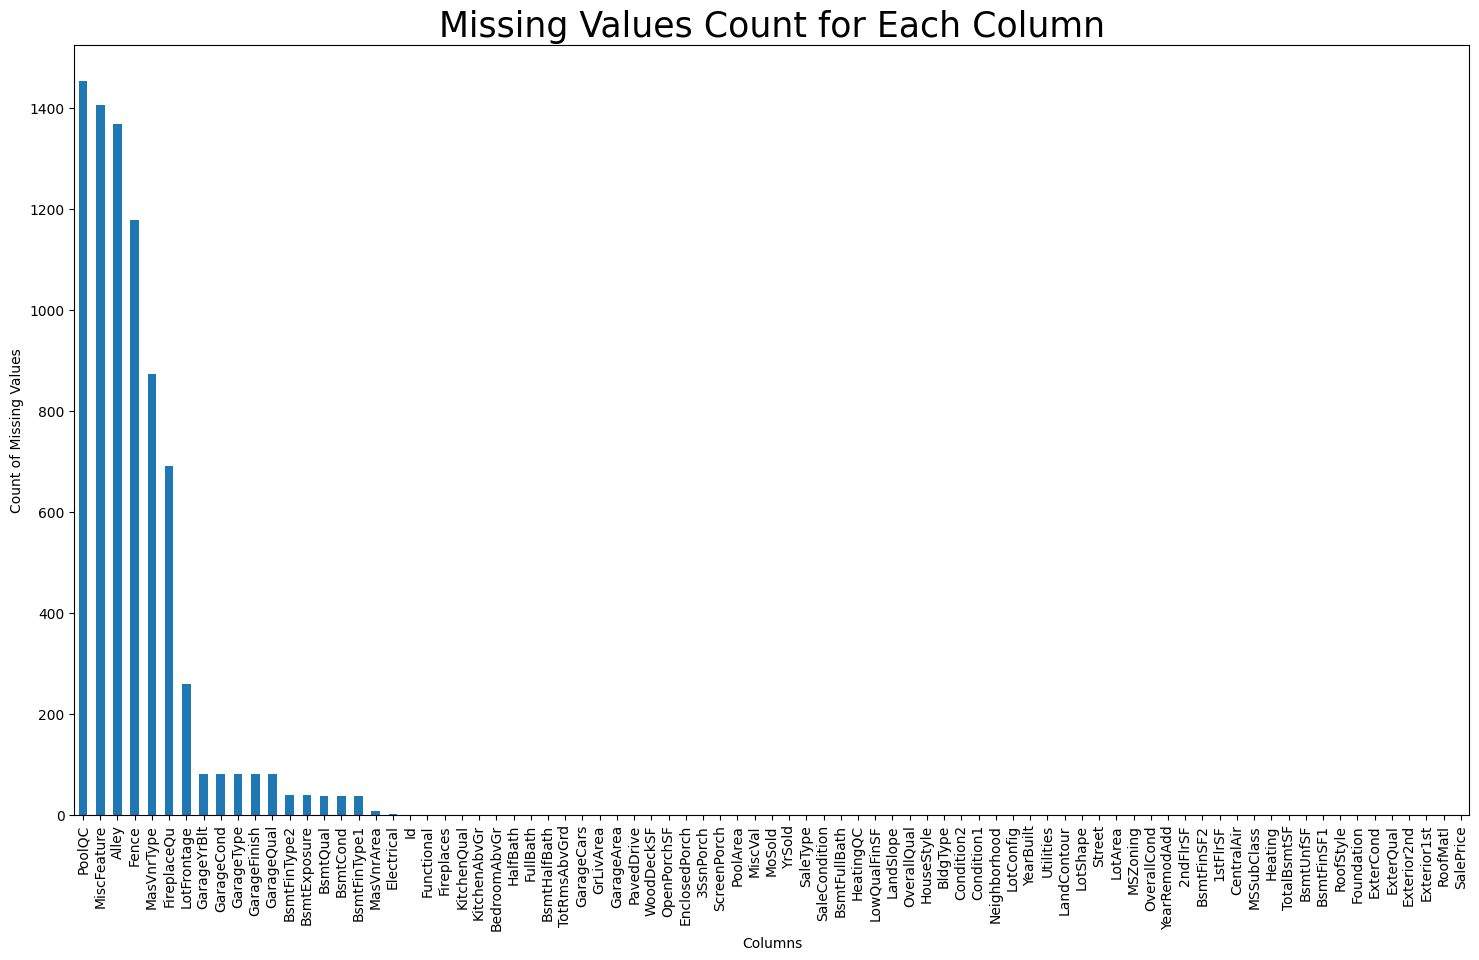

In [13]:
plt.figure(figsize=(18,10))
missing = data.isnull().sum().sort_values(ascending=False)
missing.plot(kind="bar")
plt.title("Missing Values Count for Each Column", fontsize = 25)
plt.xlabel("Columns")
plt.ylabel("Count of Missing Values")
plt.savefig(DIR_EDA/f"After_Log_Transform/missing_values_countmap/missing_values_count.png")
plt.show()

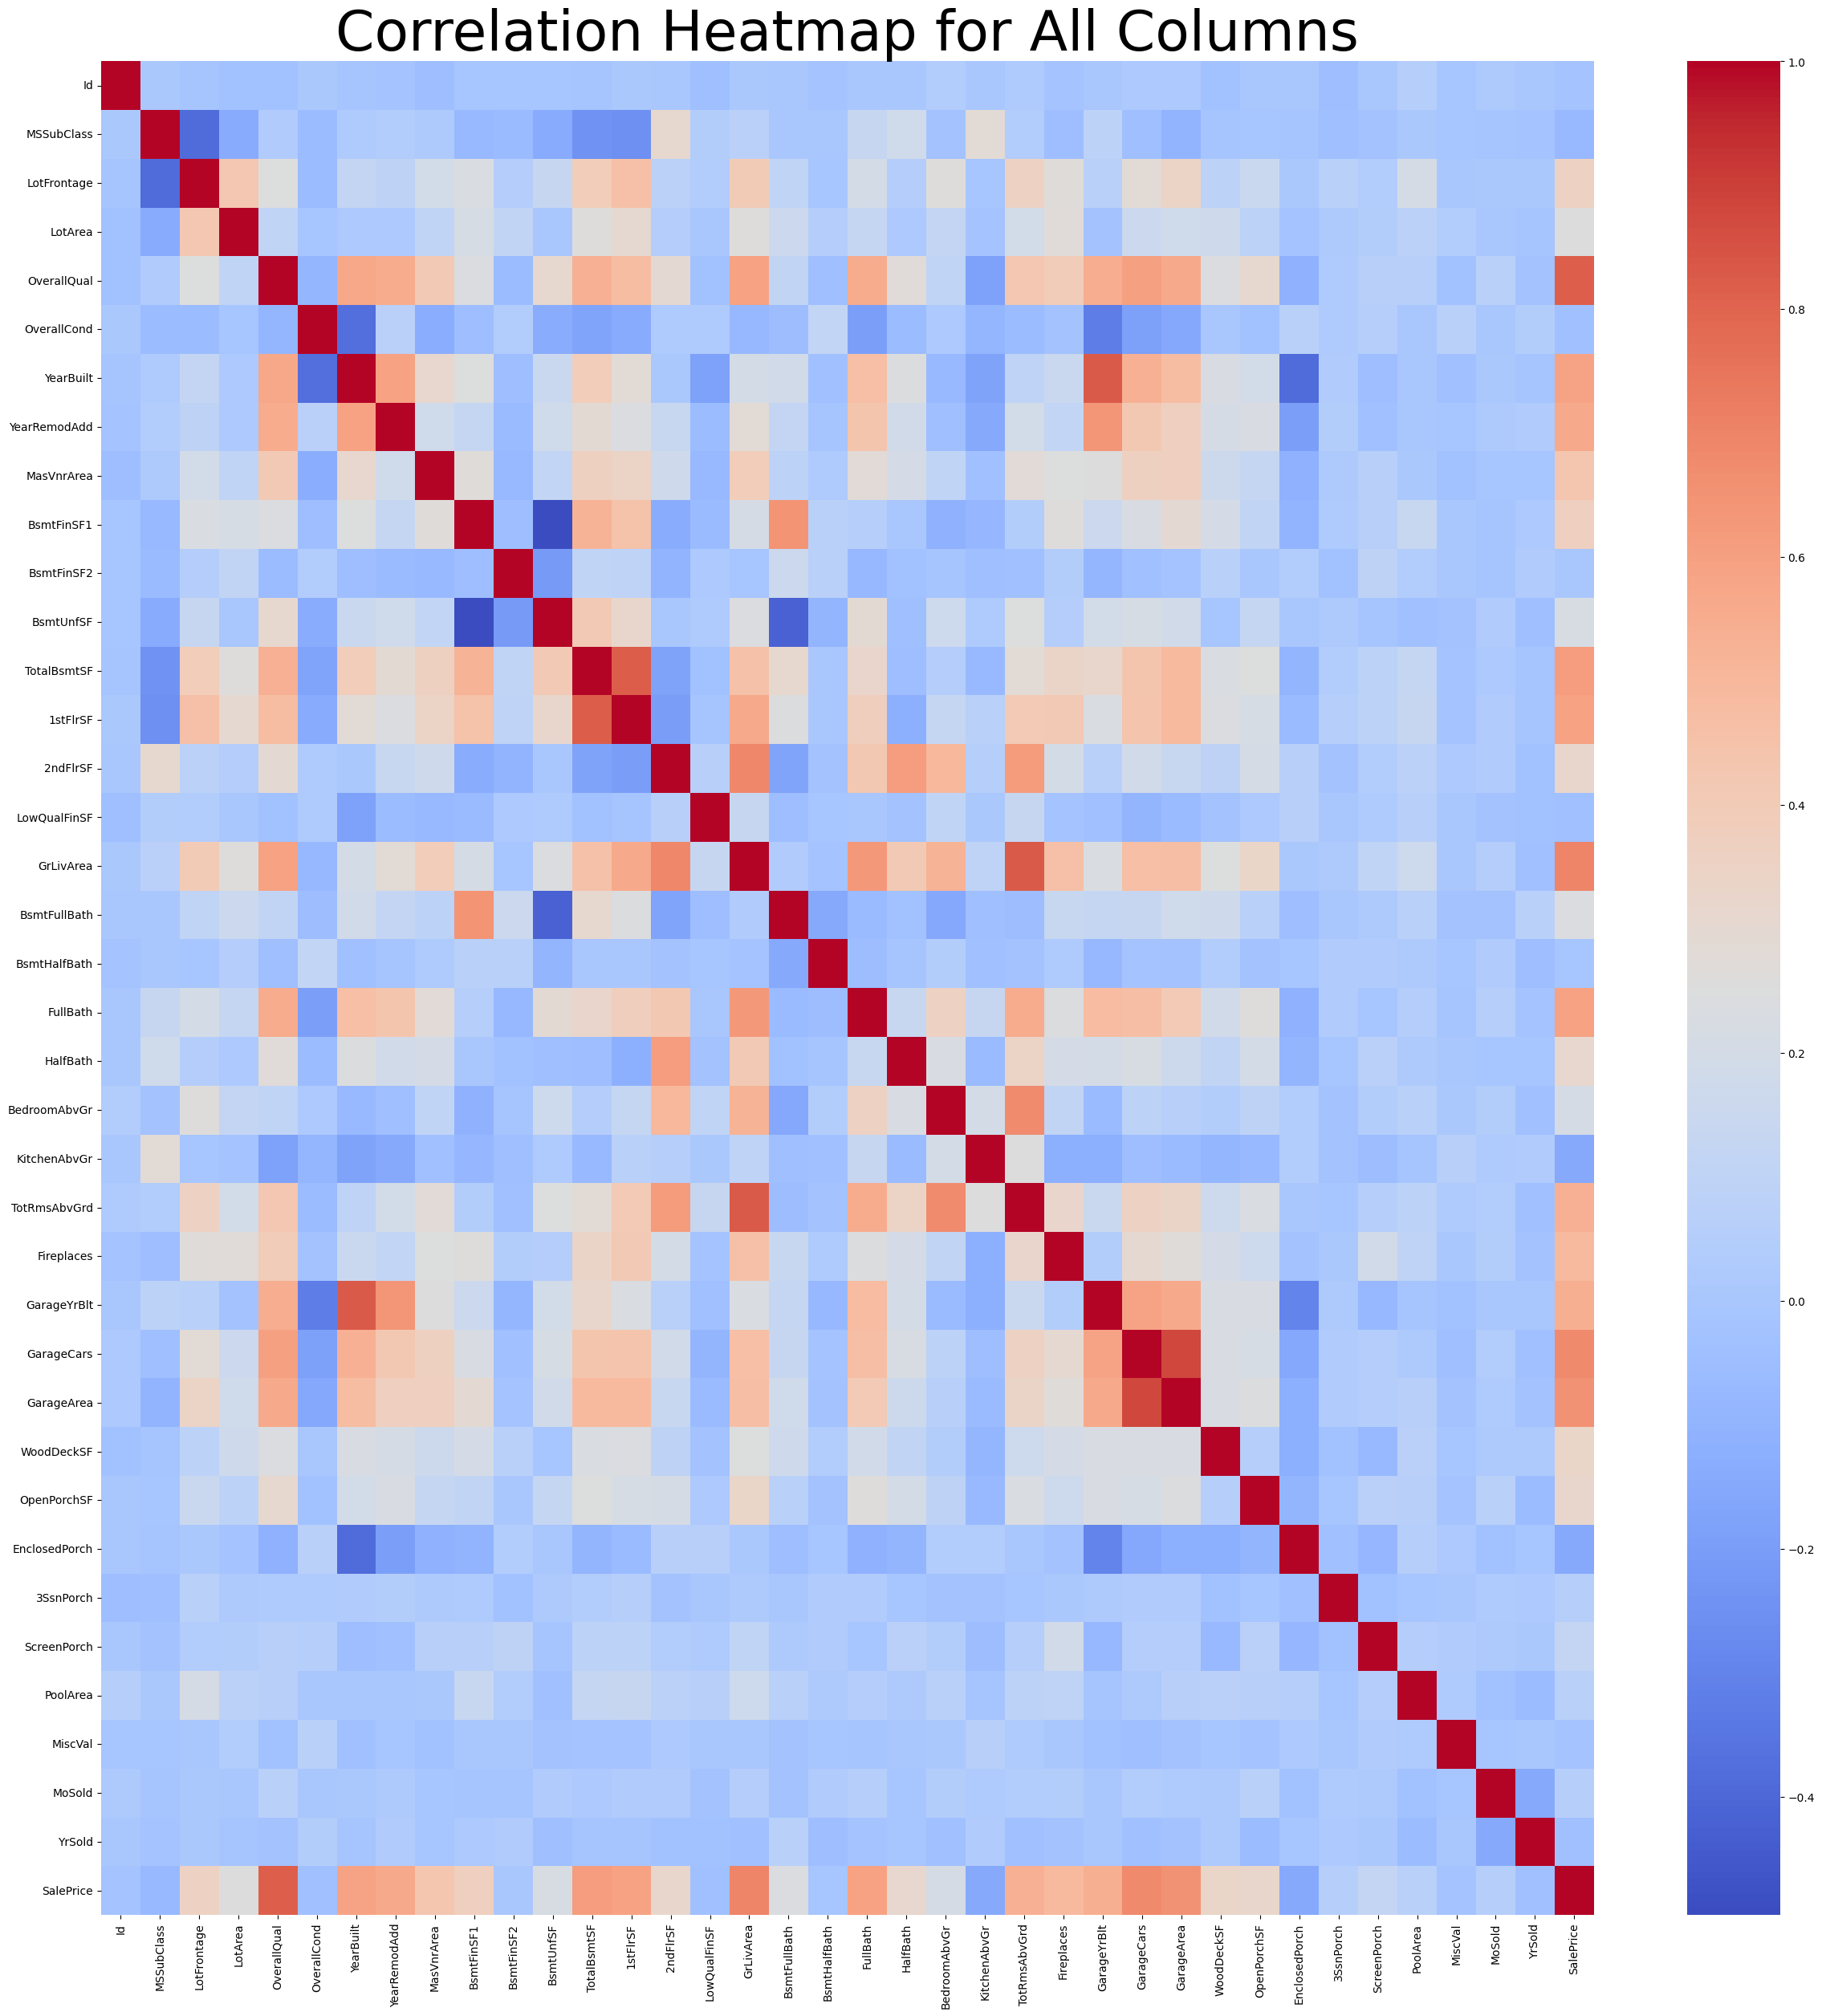

In [14]:
plt.figure(figsize = (30,30))
sns.heatmap(data.corr(numeric_only=True), cmap="coolwarm")
plt.title("Correlation Heatmap for All Columns", fontsize = 50)
plt.savefig(DIR_EDA/f"After_Log_Transform/heatmap_all_cols/heatmap_for_all_cols.png")
plt.show()

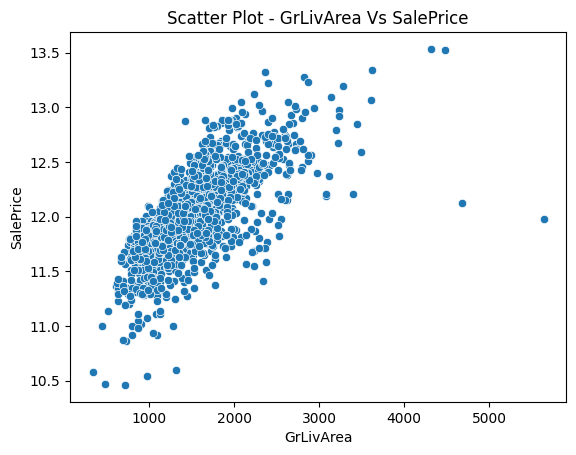

In [15]:
sns.scatterplot(x=data["GrLivArea"], y=data["SalePrice"])
plt.title("Scatter Plot - GrLivArea Vs SalePrice")
plt.xlabel("GrLivArea")
plt.ylabel("SalePrice")
plt.savefig(DIR_EDA/f"After_Log_Transform/scatter_plots_salesprice_vs_GrLiveArea/scatter_plot_GrLivArea_vs_saleprice.png")
plt.show()